## PROYECTO FINAL BOOTCAMP - **Predicción de abandono de clientes mediante Machine Learning**


# Problema real a resolver

**Contexto:**

Una empresa de telecomunicaciones está perdiendo clientes constantemente. Cada vez que un cliente cancela su servicio (Churn), la empresa pierde ingresos y además debe invertir mucho dinero en conseguir nuevos clientes.

Diversos estudios indican que retener un cliente es mucho más económico que adquirir uno nuevo.

Por ello, la empresa quiere construir un modelo de Machine Learning que permita predecir qué clientes tienen alta probabilidad de abandonar el servicio, para tomar acciones preventivas como:

- Descuentos
- Promociones
- Mejora del servicio
- Atención personalizada

**Base de datos usada:** Telco Customer Churn

**Problema de negocio:** Desarrollar un modelo de clasificación que permita predecir si un cliente abandonará o no la empresa de telecomunicaciones utilizando sus características demográficas, contractuales y de consumo. Esta herramienta permitirá implementar estrategias de fidelización enfocadas únicamente en los clientes con mayor riesgo, optimizando los recursos de la empresa y mejorando la retención.

**Variable objetivo: Churn**

- Yes → el cliente abandonó la empresa.
- No → el cliente continúa con la empresa.

Este es un problema de: **Clasificación binaria**


**Objetivo general:** Desarrollar un modelo de aprendizaje supervisado que permita predecir si un cliente abandonará o no el servicio de telecomunicaciones, utilizando técnicas de clasificación y comparando diferentes algoritmos de Machine Learning para identificar el modelo con mejor desempeño.

**Objetivos específicos**

- Explorar y comprender las características del conjunto de datos.
- Realizar el preprocesamiento necesario para preparar la información antes del entrenamiento.
- Entrenar tres modelos de clasificación diferentes.
- Evaluar el desempeño mediante métricas de clasificación.
- Comparar los modelos obtenidos.
- Seleccionar el mejor modelo justificando la decisión.

**BLOQUE 1. Importación de librerías y carga del dataset**

**1.1. Importación de librerías**

Antes de comenzar el análisis de los datos es necesario importar las librerías que se utilizarán durante todo el proyecto.

Cada una de estas librerías cumple una función específica dentro del flujo de trabajo de Ciencia de Datos. Algunas permiten manipular los datos, otras crear visualizaciones y otras serán utilizadas posteriormente para construir y evaluar modelos de Machine Learning.

Posteriormente se cargará el conjunto de datos **Telco Customer Churn**, el cual contiene información de clientes de una empresa de telecomunicaciones y será la base para desarrollar el modelo de clasificación.

Finalmente, se verificará que el archivo se haya cargado correctamente visualizando las primeras filas del dataset.

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# División del conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Transformación de variables categóricas a valores numéricos
from sklearn.preprocessing import LabelEncoder

# Escalado de variables numéricas
from sklearn.preprocessing import StandardScaler

# Métricas de evaluación
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


**1.2. Carga del conjunto de datos**

Una vez importadas las librerías, se procede a cargar el conjunto de datos.

El archivo utilizado corresponde al dataset **Telco Customer Churn**, el cual contiene información demográfica, contractual y de facturación de clientes de una empresa de telecomunicaciones.

Cada fila representa un cliente y cada columna describe una característica del mismo.

La variable objetivo del proyecto será **Churn**, la cual indica si un cliente abandonó el servicio ("Yes") o permaneció en la empresa ("No").

In [2]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Cargar el conjunto de datos
df = pd.read_csv("Telco-Customer-Churn-DATASET.csv")

# Mostrar las primeras cinco filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**BLOQUE 2. Exploración inicial del dataset**

**2.1. Exploración inicial del conjunto de datos**

El Análisis Exploratorio de Datos (EDA) constituye una de las etapas más importantes dentro de un proyecto de Machine Learning.

Su propósito es comprender la estructura del conjunto de datos, identificar posibles problemas de calidad, conocer el tipo de variables disponibles y detectar patrones que puedan influir posteriormente en el entrenamiento de los modelos.

En esta sección se analizarán aspectos fundamentales como:

- Dimensiones del dataset.
- Tipos de datos.
- Valores faltantes.
- Registros duplicados.
- Variables categóricas y numéricas.
- Estadísticas descriptivas.

Esta información permitirá definir las estrategias de limpieza y preprocesamiento necesarias antes de construir los modelos de clasificación.

*2.1.1. Dimensiones del conjunto de datos*

Como primer paso se analizará el tamaño del conjunto de datos.

Conocer el número de registros (filas) y variables (columnas) permite tener una visión general del problema y verificar que el dataset fue cargado correctamente.

Conocer las dimensiones del conjunto de datos permite identificar el tamaño del problema que se abordará. El número de filas representa la cantidad total de clientes registrados en la base de datos, mientras que el número de columnas corresponde a las variables disponibles para describir el comportamiento de cada cliente.

Esta información es importante porque permite estimar la cantidad de datos disponibles para entrenar modelos de Machine Learning y evaluar si el conjunto de datos posee un tamaño adecuado para realizar un análisis confiable.

In [3]:
# ======================================================
# DIMENSIONES DEL DATASET
# ======================================================

print("="*50)
print("DIMENSIONES DEL DATASET")
print("="*50)

filas, columnas = df.shape

print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")

DIMENSIONES DEL DATASET
Número de filas: 7043
Número de columnas: 21


*2.1.2. Información general del dataset*

A continuación se inspeccionará la estructura general del conjunto de datos mediante la función `info()`.

Esta función proporciona información sobre:

- Número de registros.
- Nombre de las variables.
- Tipo de dato de cada columna.
- Cantidad de valores no nulos.
- Consumo de memoria.

La salida de `info()` permite identificar rápidamente si existen variables con tipos de datos incorrectos o columnas con valores faltantes.

Esta información será utilizada posteriormente durante el proceso de preprocesamiento para realizar las transformaciones necesarias antes del entrenamiento de los modelos.

In [4]:
# ============================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

*2.1.3 Primeras observaciones del conjunto de datos*

Visualizar las primeras filas del dataset permite conocer la estructura de la información almacenada y verificar que los datos fueron cargados correctamente.

La inspección visual del dataset permite identificar la forma en que se encuentran organizadas las variables y comprobar que cada registro corresponde a un cliente distinto.

Además, facilita detectar posibles inconsistencias antes de iniciar el análisis estadístico.

In [5]:
# Primeras filas

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Últimas filas

df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


*2.1.4. Identificación de valores faltantes*

Los valores faltantes pueden afectar significativamente el rendimiento de un modelo de Machine Learning.

Por esta razón, es importante identificar qué variables presentan datos ausentes y cuántos registros están involucrados.

In [7]:
# ======================================================
# VALORES FALTANTES
# ======================================================

valores_nulos = df.isnull().sum()

tabla_nulos = pd.DataFrame({
    'Valores nulos': valores_nulos,
    'Porcentaje (%)': (valores_nulos/len(df))*100
})

tabla_nulos = tabla_nulos[tabla_nulos['Valores nulos']>0]

tabla_nulos.sort_values(by='Valores nulos',ascending=False)

,Valores nulos,Porcentaje (%)


Esta tabla permite identificar las variables que contienen valores faltantes, así como el porcentaje que estos representan con respecto al total de registros del conjunto de datos. A partir de esta información, es posible definir la estrategia de tratamiento más adecuada, ya sea mediante la imputación de los valores ausentes, la transformación de las variables o la eliminación de registros, según la magnitud del problema.

Finalmente, tras ejecutar el código, se observó que el conjunto de datos no presenta valores nulos. Por lo tanto, no fue necesario aplicar técnicas de imputación ni realizar un tratamiento adicional relacionado con datos faltantes.

*2.1.5. Identificación de registros duplicados*

Los registros duplicados pueden introducir sesgos durante el entrenamiento del modelo, ya que un mismo cliente estaría siendo considerado varias veces.

Por ello se verificará si existen observaciones repetidas.

In [8]:
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


En caso de haberse identificado registros duplicados, habría sido necesario analizar si correspondían a observaciones realmente repetidas o si representaban entidades distintas con características similares.

Si, después de la revisión, se hubiera confirmado que se trataba de duplicados exactos, dichos registros se habrían eliminado durante la etapa de preprocesamiento para evitar sesgos en el análisis y en el entrenamiento del modelo.

Finalmente, tras ejecutar el análisis, se verificó que el conjunto de datos no presenta registros duplicados, por lo que no fue necesario eliminar observaciones durante el proceso de preprocesamiento.

*2.1.6. Variables categóricas y numéricas*

In [9]:
categoricas = df.select_dtypes(include=['object']).columns

numericas = df.select_dtypes(include=['int64','float64']).columns

print("Variables categóricas")
print(categoricas)

print("\n")

print("Variables numéricas")
print(numericas)

Variables categóricas
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


Variables numéricas
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


C:\Users\liz00\AppData\Local\Temp\ipykernel_11964\3078353038.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns


La separación entre variables categóricas y numéricas es importante porque cada tipo de dato requiere técnicas de preprocesamiento diferentes.
Las variables categóricas deberán codificarse antes del entrenamiento de los modelos, mientras que algunas variables numéricas requerirán procesos de escalado.

Se clasificaron las variables del conjunto de datos de acuerdo con su tipo de dato, diferenciando entre variables categóricas y variables numéricas. Esta clasificación es fundamental para definir las técnicas de preprocesamiento y análisis que se aplicarán posteriormente, ya que las variables categóricas requieren procesos de codificación, mientras que las variables numéricas pueden utilizarse directamente o someterse a procesos de normalización o estandarización.

*2.1.7. Estadísticas descriptivas*

Las estadísticas descriptivas permiten resumir el comportamiento de las variables numéricas mediante medidas como:

- Media
- Desviación estándar
- Valor mínimo
- Cuartiles
- Valor máximo

Estas medidas ayudan a comprender la distribución de los datos y detectar posibles valores atípicos.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


*2.1.8. Distribución de la variable objetivo*

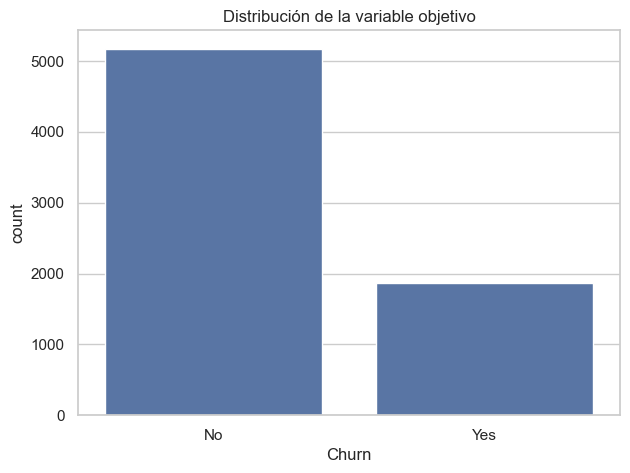

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x='Churn')

plt.title("Distribución de la variable objetivo")

plt.show()

In [12]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

La distribución de la variable objetivo permite identificar si el conjunto de datos se encuentra balanceado o desbalanceado.

Esta información es importante porque un desbalance significativo podría afectar el desempeño de algunos algoritmos de clasificación y requerir técnicas específicas durante el entrenamiento.

Se analizó la distribución de la variable objetivo Churn, observándose que el 73.46 % de los clientes pertenece a la categoría "No", mientras que el 26.54 % corresponde a la categoría "Yes". Esto indica que el conjunto de datos presenta un desbalance moderado entre las clases, ya que la categoría mayoritaria contiene una proporción considerablemente mayor de observaciones. Aunque este nivel de desbalance no es severo, deberá tenerse en cuenta durante el entrenamiento y la evaluación del modelo, empleando métricas adecuadas para valorar su desempeño sobre ambas clases.

**BLOQUE 3. Prepropcesamiento de los datos**

Una vez finalizado el análisis exploratorio de los datos (EDA), se inicia la etapa de preprocesamiento. Esta fase tiene como propósito preparar el conjunto de datos para que pueda ser utilizado correctamente por los algoritmos de Machine Learning.

**3.1 Eliminación de columnas innecesarias**

El primer paso consiste en identificar aquellas variables que no aportan información relevante para el proceso de aprendizaje del modelo.

En este conjunto de datos existe la variable **customerID**, la cual corresponde únicamente a un identificador único asignado a cada cliente.

Aunque esta columna permite diferenciar cada registro, no contiene información relacionada con el comportamiento del cliente ni contribuye a explicar el abandono del servicio (**Churn**). Por esta razón, mantenerla podría introducir ruido durante el entrenamiento del modelo y afectar su capacidad de generalización.

En consecuencia, esta variable será eliminada antes de continuar con el preprocesamiento.

In [13]:
# ==========================================================
# ELIMINACIÓN DE COLUMNAS NO RELEVANTES
# ==========================================================

# Mostrar las columnas actuales del dataset
print("Columnas disponibles en el conjunto de datos:\n")
print(df.columns.tolist())

Columnas disponibles en el conjunto de datos:

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


La instrucción anterior permite visualizar todas las variables disponibles en el conjunto de datos antes de realizar cualquier modificación.

Esta revisión facilita identificar las columnas que pueden aportar información útil para el modelo y aquellas que únicamente funcionan como identificadores o metadatos.

In [14]:
# ==========================================================
# ELIMINAR LA COLUMNA customerID
# ==========================================================

# Eliminar la columna customerID
df = df.drop(columns=["customerID"])

print("La columna 'customerID' ha sido eliminada correctamente.")

La columna 'customerID' ha sido eliminada correctamente.


In [15]:
# ==========================================================
# VERIFICAR EL RESULTADO
# ==========================================================

print("Columnas actuales del dataset:\n")
print(df.columns.tolist())

print("\n")

print(f"Número de variables después de la eliminación: {df.shape[1]}")

Columnas actuales del dataset:

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Número de variables después de la eliminación: 20


Después de eliminar la columna **customerID**, se verifica nuevamente la estructura del conjunto de datos para confirmar que la operación se realizó correctamente.

La eliminación de esta variable no representa una pérdida de información útil para el modelo, ya que únicamente identificaba de manera única a cada cliente y no describía características relacionadas con su comportamiento.

Con esta transformación se reduce el riesgo de que el modelo aprenda patrones asociados a identificadores únicos, lo cual no tendría capacidad predictiva sobre la variable objetivo (**Churn**).

**3.2 Conversión de tipos de datos**

Una vez eliminadas las columnas que no aportan información al modelo, el siguiente paso consiste en verificar que cada variable tenga asignado el tipo de dato correcto.

Los algoritmos de Machine Learning requieren que las variables numéricas estén almacenadas como datos de tipo entero (`int`) o decimal (`float`). Sin embargo, durante la carga del conjunto de datos algunas columnas pueden ser interpretadas como texto debido a inconsistencias en su contenido.

En el dataset **Telco Customer Churn**, la variable **TotalCharges** representa el costo total pagado por cada cliente desde el inicio de su contrato y debería ser una variable numérica.

No obstante, esta columna fue almacenada como tipo `object`, debido a la existencia de algunos registros con espacios en blanco, los cuales impiden su conversión automática a formato numérico.

En esta sección se identificará el tipo de dato actual de la variable, posteriormente se realizará la conversión a formato numérico y finalmente se verificará que el proceso se haya realizado correctamente.

In [16]:
# ==========================================================
# VERIFICAR EL TIPO DE DATO DE TotalCharges
# ==========================================================

print("Tipo de dato antes de la conversión:\n")
print(df["TotalCharges"].dtype)

Tipo de dato antes de la conversión:

str


La salida confirma que la variable **TotalCharges** está almacenada como tipo **object**, es decir, como texto.

Este tipo de dato no es adecuado para representar valores monetarios ni puede ser utilizado directamente por los algoritmos de Machine Learning, por lo que será necesario convertirla a un tipo de dato numérico.

In [17]:
# ==========================================================
# IDENTIFICAR REGISTROS CON ESPACIOS EN BLANCO
# ==========================================================

# Buscar registros donde TotalCharges contiene únicamente espacios
espacios = df[df["TotalCharges"].str.strip() == ""]

print(f"Número de registros con espacios en blanco: {len(espacios)}")

# Visualizar algunos ejemplos
espacios.head()

Número de registros con espacios en blanco: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


Los registros mostrados corresponden a clientes cuya variable **TotalCharges** contiene únicamente espacios en blanco.

Estos valores no representan información válida y son la principal razón por la cual la columna fue interpretada como texto durante la carga del dataset.

En el siguiente paso estos espacios serán convertidos en valores nulos (`NaN`) para permitir la transformación de la variable a formato numérico.

In [18]:
# ==========================================================
# CONVERTIR TotalCharges A FORMATO NUMÉRICO
# ==========================================================

# Convertir la columna a tipo numérico
# Los valores no convertibles se reemplazan por NaN

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

**Comentario para el código:**
errors="coerce" indica que cualquier valor que no pueda convertirse en número (como los espacios en blanco) será reemplazado automáticamente por NaN.

In [19]:
# ==========================================================
# VERIFICAR LA CONVERSIÓN
# ==========================================================

print("Tipo de dato después de la conversión:\n")
print(df["TotalCharges"].dtype)

print("\nCantidad de valores nulos generados:")

print(df["TotalCharges"].isnull().sum())

Tipo de dato después de la conversión:

float64

Cantidad de valores nulos generados:
11


Después de la conversión, la variable **TotalCharges** pasó de tipo **object** a tipo **float64**, lo cual confirma que ahora puede ser utilizada por los modelos de Machine Learning.

Adicionalmente, se observa que algunos registros fueron convertidos en valores nulos (`NaN`). Esto era esperado, ya que originalmente contenían espacios en blanco en lugar de un valor numérico.

Estos valores faltantes serán tratados en la siguiente etapa del preprocesamiento para garantizar la calidad del conjunto de datos antes del entrenamiento de los modelos.

In [20]:
# ==========================================================
# RESUMEN DE LA VARIABLE TotalCharges
# ==========================================================

print(df["TotalCharges"].describe())

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


El resumen estadístico confirma que la variable **TotalCharges** ahora es reconocida como una variable numérica.

A partir de este momento es posible calcular estadísticas descriptivas, generar visualizaciones y utilizar esta variable durante el entrenamiento de los modelos de clasificación.

**3.3. Tratamiento de valores faltantes**

Una vez convertida la variable **TotalCharges** a formato numérico, algunos registros fueron transformados en valores nulos (`NaN`). Esto ocurrió porque originalmente contenían espacios en blanco en lugar de un valor numérico.

Los valores faltantes representan un problema para la mayoría de los algoritmos de Machine Learning, ya que estos requieren información completa para realizar el proceso de entrenamiento.

Antes de decidir cómo tratarlos, es importante identificar cuántos valores faltantes existen, en qué variables se encuentran y cuál es su proporción respecto al tamaño total del conjunto de datos.

Posteriormente se seleccionará la estrategia más adecuada para su tratamiento, justificando la decisión desde el punto de vista del negocio y de las buenas prácticas en Ciencia de Datos.

In [21]:
# ==========================================================
# IDENTIFICACIÓN DE VALORES FALTANTES
# ==========================================================

# Contar los valores nulos por columna
valores_nulos = df.isnull().sum()

# Crear una tabla resumen
tabla_nulos = pd.DataFrame({
    "Valores nulos": valores_nulos,
    "Porcentaje (%)": round((valores_nulos / len(df)) * 100, 2)
})

# Mostrar únicamente las columnas con valores faltantes
tabla_nulos[tabla_nulos["Valores nulos"] > 0]

,Valores nulos,Porcentaje (%)
TotalCharges,11,0.16


La tabla anterior muestra las variables que contienen valores faltantes y el porcentaje que representan dentro del conjunto de datos.

Se observa que únicamente la variable **TotalCharges** presenta valores nulos, los cuales corresponden a los registros que anteriormente contenían espacios en blanco.

Además, el porcentaje de valores faltantes es muy bajo respecto al tamaño total del dataset, por lo que no representa un problema significativo para el desarrollo del modelo.

In [22]:
# ==========================================================
# INSPECCIONAR LOS REGISTROS CON VALORES NULOS
# ==========================================================

# Mostrar los registros donde TotalCharges es nulo
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Al inspeccionar los registros con valores faltantes se observa que corresponden a clientes con una antigüedad (**tenure**) igual a cero meses.

Esto significa que son clientes que acaban de ingresar a la empresa y, por lo tanto, aún no han realizado ningún pago. En consecuencia, no existe un valor válido para la variable **TotalCharges**.

Esta situación explica por qué dichos registros presentan valores faltantes y permite tomar una decisión fundamentada sobre su tratamiento.

In [23]:
# ==========================================================
# CANTIDAD DE REGISTROS A ELIMINAR
# ==========================================================

print(f"Número de registros antes del tratamiento: {len(df)}")

print(f"Registros con valores nulos: {df['TotalCharges'].isnull().sum()}")

print(f"Porcentaje de registros afectados: {(df['TotalCharges'].isnull().sum()/len(df))*100:.3f}%")

Número de registros antes del tratamiento: 7043
Registros con valores nulos: 11
Porcentaje de registros afectados: 0.156%


Los registros con valores faltantes representan un porcentaje muy pequeño del conjunto de datos.

Debido a que corresponden a menos del 1 % de las observaciones, eliminarlos no afecta de manera significativa la cantidad de información disponible para entrenar los modelos.

Por esta razón, en este proyecto se optará por eliminar dichos registros en lugar de imputar un valor estimado, evitando introducir información artificial que pueda afectar el desempeño del modelo.

In [24]:
# ==========================================================
# ELIMINAR REGISTROS CON VALORES NULOS
# ==========================================================

# Eliminar filas con valores nulos
df = df.dropna()

print("Registros después del tratamiento:", len(df))

Registros después del tratamiento: 7032


**3.4 Verificación final de valores nulos**

Después de realizar el tratamiento de los valores faltantes, es importante verificar nuevamente la calidad del conjunto de datos antes de continuar con las siguientes etapas del preprocesamiento.

Esta verificación tiene como finalidad confirmar que todas las variables contienen información completa y que no existen registros con valores nulos que puedan generar errores durante la codificación de variables o el entrenamiento de los modelos de Machine Learning.

Realizar este tipo de validaciones constituye una buena práctica dentro del flujo de trabajo de Ciencia de Datos, ya que permite garantizar la consistencia e integridad del conjunto de datos antes de aplicar transformaciones más complejas.

In [25]:
# ==========================================================
# VERIFICACIÓN FINAL
# ==========================================================

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

La verificación final confirma que el conjunto de datos ya no presenta valores faltantes.

Contar con un dataset libre de valores nulos garantiza que los algoritmos de Machine Learning puedan procesar correctamente la información durante el entrenamiento y la evaluación de los modelos.

Con este paso se finaliza el tratamiento de los valores faltantes y el conjunto de datos queda preparado para las siguientes transformaciones del preprocesamiento.

In [26]:
# ==========================================================
# RESUMEN DE LA VALIDACIÓN
# ==========================================================

total_nulos = df.isnull().sum().sum()

print("=" * 60)

if total_nulos == 0:
    print("El conjunto de datos no presenta valores nulos.")
    print("El dataset está listo para continuar con el preprocesamiento.")
else:
    print(f"Se encontraron {total_nulos} valores nulos en el dataset.")

print("=" * 60)

El conjunto de datos no presenta valores nulos.
El dataset está listo para continuar con el preprocesamiento.


La validación confirma que el conjunto de datos ya no presenta valores faltantes.

Esto significa que todas las variables contienen información completa, condición necesaria para aplicar correctamente las técnicas de codificación y posteriormente entrenar los modelos de clasificación.

Al finalizar esta etapa se garantiza que el dataset posee una estructura consistente y está preparado para continuar con el proceso de transformación de las variables.

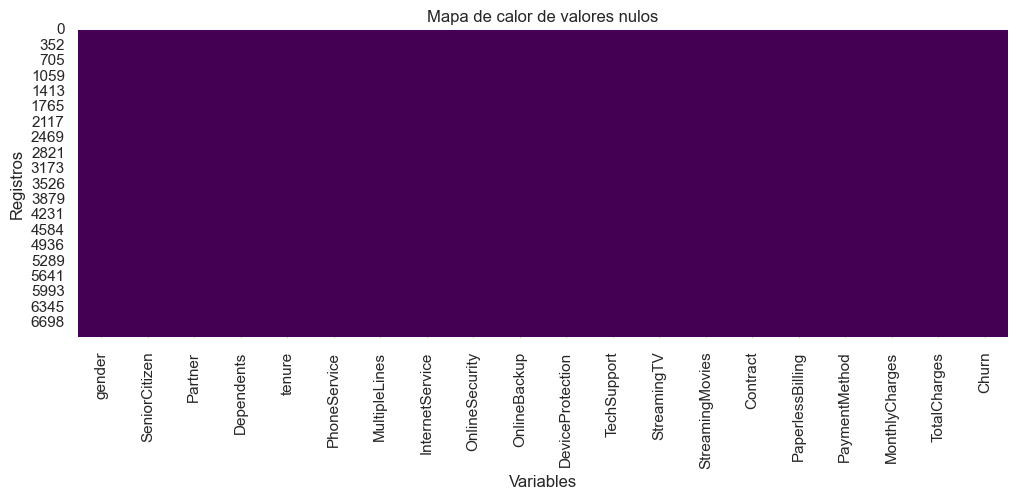

In [27]:
# ==========================================================
# VISUALIZACIÓN DE VALORES NULOS
# ==========================================================

plt.figure(figsize=(12,4))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Mapa de calor de valores nulos")

plt.xlabel("Variables")

plt.ylabel("Registros")

plt.show()

El mapa de calor permite identificar visualmente la presencia de valores faltantes en el conjunto de datos.

Cada columna representa una variable y cada fila corresponde a un cliente. Si existieran valores nulos, estos aparecerían resaltados en el gráfico.

En este caso, el mapa de calor muestra una distribución uniforme sin interrupciones, lo que confirma que todas las observaciones contienen información completa y que el conjunto de datos está listo para las siguientes etapas del preprocesamiento.

**3.5 Codificación de variables categóricas mediante One-Hot Encoding**

La mayoría de los algoritmos de Machine Learning trabajan únicamente con variables numéricas. Sin embargo, el conjunto de datos utilizado en este proyecto contiene varias variables categóricas, como el género del cliente, el tipo de contrato, el servicio de internet y el método de pago.

Estas variables contienen información importante para explicar el abandono de los clientes, pero no pueden ser utilizadas directamente por los modelos de clasificación.

Para solucionar este problema se aplicará la técnica **One-Hot Encoding**, la cual transforma cada categoría en una nueva variable binaria (0 o 1), permitiendo que los algoritmos interpreten correctamente la información sin introducir un orden artificial entre las categorías.

Es importante mencionar que esta transformación se aplicará únicamente a las variables predictoras. La variable objetivo **Churn** será codificada posteriormente mediante Label Encoding debido a que únicamente posee dos categorías ("Yes" y "No").

In [28]:
# ==========================================================
# IDENTIFICACIÓN DE VARIABLES CATEGÓRICAS
# ==========================================================

# Seleccionar todas las variables de tipo objeto,
# excepto la variable objetivo (Churn)

variables_categoricas = df.select_dtypes(include='object').columns.drop('Churn')

print("Variables categóricas que serán codificadas:\n")

for variable in variables_categoricas:
    print(f"• {variable}")

print(f"\nNúmero de variables categóricas: {len(variables_categoricas)}")

Variables categóricas que serán codificadas:

• gender
• Partner
• Dependents
• PhoneService
• MultipleLines
• InternetService
• OnlineSecurity
• OnlineBackup
• DeviceProtection
• TechSupport
• StreamingTV
• StreamingMovies
• Contract
• PaperlessBilling
• PaymentMethod

Número de variables categóricas: 15


C:\Users\liz00\AppData\Local\Temp\ipykernel_11964\3102558002.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df.select_dtypes(include='object').columns.drop('Churn')


La salida anterior muestra todas las variables categóricas que serán transformadas mediante One-Hot Encoding.

Estas variables representan características importantes de los clientes, como los servicios contratados, el tipo de contrato y el método de pago.

Debido a que estas variables son de naturaleza nominal, no existe un orden entre sus categorías. Por ello, One-Hot Encoding es la técnica más adecuada para convertirlas en variables numéricas sin alterar su significado.

In [29]:
# ==========================================================
# APLICAR ONE-HOT ENCODING
# ==========================================================

# Guardar el número de columnas antes de la transformación
columnas_antes = df.shape[1]

# drop_first=True elimina una de las categorías de cada variable
# para evitar multicolinealidad (Dummy Variable Trap).

# Aplicar One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=variables_categoricas,
    drop_first=True,
    dtype=int
)

# Número de columnas después de la transformación
columnas_despues = df.shape[1]

print(f"Columnas antes del One-Hot Encoding: {columnas_antes}")
print(f"Columnas después del One-Hot Encoding: {columnas_despues}")
print(f"Nuevas variables creadas: {columnas_despues-columnas_antes}")

Columnas antes del One-Hot Encoding: 20
Columnas después del One-Hot Encoding: 31
Nuevas variables creadas: 11


Después de aplicar One-Hot Encoding, cada categoría de las variables categóricas fue transformada en una variable binaria.

Como resultado, el número de columnas del conjunto de datos aumentó, ya que cada categoría pasó a representarse mediante una nueva variable con valores de 0 y 1.

Además, se utilizó el parámetro **drop_first=True**, el cual elimina una de las categorías de cada variable para evitar problemas de multicolinealidad entre las variables generadas.

In [30]:
# ==========================================================
# VERIFICAR EL DATASET DESPUÉS DEL ONE-HOT ENCODING
# ==========================================================

print("Primeras filas del nuevo conjunto de datos:")

df.head()

Primeras filas del nuevo conjunto de datos:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,No,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,No,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,Yes,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,No,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,Yes,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


La visualización de las primeras filas permite comprobar que las variables categóricas originales fueron reemplazadas por nuevas variables binarias.

Cada una de estas nuevas variables indica la presencia (1) o ausencia (0) de una determinada categoría.

Esta representación es adecuada para los algoritmos de Machine Learning, ya que toda la información del conjunto de datos se encuentra ahora en formato numérico, con excepción de la variable objetivo **Churn**, la cual será transformada en la siguiente sección.

In [31]:
# ==========================================================
# VERIFICAR LOS TIPOS DE DATOS
# ==========================================================

df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   str    
 5   gender_Male                            7032 non-null   int64  
 6   Partner_Yes                            7032 non-null   int64  
 7   Dependents_Yes                         7032 non-null   int64  
 8   PhoneService_Yes                       7032 non-null   int64  
 9   MultipleLines_No phone service         7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetService_Fibe

La verificación de los tipos de datos confirma que las variables categóricas fueron convertidas correctamente en variables numéricas de tipo entero (`int`).

En este punto del preprocesamiento, la única variable que permanece como tipo categórico es **Churn**, ya que será codificada mediante Label Encoding en la siguiente etapa.

**3.6 Codificación de la variable objetivo mediante Label Encoding**

Después de transformar las variables predictoras mediante One-Hot Encoding, el siguiente paso consiste en preparar la variable objetivo (**Churn**) para que pueda ser utilizada durante el entrenamiento de los modelos de clasificación.

Actualmente, la variable **Churn** almacena valores categóricos ("Yes" y "No"), mientras que los algoritmos de Machine Learning requieren que la variable objetivo esté representada mediante valores numéricos.

Debido a que esta variable únicamente posee dos categorías, se utilizará la técnica **Label Encoding**, la cual asigna un valor entero a cada clase.

En este proyecto, la codificación permitirá representar la clase **"No"** mediante el valor **0** y la clase **"Yes"** mediante el valor **1**, facilitando así el entrenamiento y la evaluación de los modelos de clasificación.

In [32]:
# ==========================================================
# VERIFICAR LA VARIABLE OBJETIVO
# ==========================================================

print("Valores únicos de la variable Churn:")

print(df["Churn"].unique())

print("\nFrecuencia de cada categoría:")

print(df["Churn"].value_counts())

Valores únicos de la variable Churn:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Frecuencia de cada categoría:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


La variable objetivo **Churn** contiene dos categorías:

- **No:** el cliente continúa utilizando los servicios de la empresa.
- **Yes:** el cliente abandonó la empresa.

Al tratarse de una variable binaria, resulta apropiado utilizar Label Encoding para convertir estas categorías en valores numéricos sin perder su significado.

In [33]:
# ==========================================================
# CODIFICAR LA VARIABLE OBJETIVO
# ==========================================================

# Crear el codificador
label_encoder = LabelEncoder()

# Aplicar Label Encoding
df["Churn"] = label_encoder.fit_transform(df["Churn"])

print("Codificación realizada correctamente.")

Codificación realizada correctamente.


In [34]:
# ==========================================================
# VERIFICAR LA CODIFICACIÓN
# ==========================================================

print(df["Churn"].value_counts())

print("\n")

print("Valores únicos:")

print(df["Churn"].unique())

Churn
0    5163
1    1869
Name: count, dtype: int64


Valores únicos:
[0 1]


La variable **Churn** fue transformada correctamente mediante Label Encoding.

Ahora la variable objetivo está representada mediante valores numéricos:

- **0:** Cliente que permanece en la empresa.
- **1:** Cliente que abandona la empresa.

Esta representación es compatible con los algoritmos de clasificación implementados en Scikit-Learn y será utilizada durante el entrenamiento y evaluación de los modelos.

In [35]:
# ==========================================================
# VERIFICAR EL TIPO DE DATO
# ==========================================================

print(df["Churn"].dtype)

int64


La verificación confirma que la variable objetivo ahora se encuentra almacenada como un dato numérico entero.

Con esta transformación, todas las variables del conjunto de datos se encuentran en un formato adecuado para ser utilizadas por los algoritmos de Machine Learning.

In [36]:
# ==========================================================
# VISUALIZAR EL DATASET ACTUALIZADO
# ==========================================================

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


La visualización de las primeras filas del conjunto de datos permite comprobar que todas las variables predictoras y la variable objetivo se encuentran ahora representadas mediante valores numéricos.

Este resultado confirma que el proceso de codificación fue exitoso y que el conjunto de datos está listo para las etapas de preparación para el entrenamiento de los modelos.

**3.7 Separación entre variables predictoras y variable objetivo**

Una vez finalizado el proceso de limpieza y transformación de los datos, el siguiente paso consiste en separar las variables predictoras de la variable objetivo.

En un problema de aprendizaje supervisado, los algoritmos de Machine Learning aprenden la relación existente entre un conjunto de variables de entrada (variables predictoras) y una variable de salida (variable objetivo).

En este proyecto:

- Las **variables predictoras (X)** corresponden a todas las características de los clientes, como su antigüedad, tipo de contrato, servicios contratados y cargos asociados.
- La **variable objetivo (y)** corresponde a la variable **Churn**, la cual indica si un cliente abandonó (1) o permaneció (0) en la empresa.

Esta separación es un requisito indispensable antes de dividir los datos en conjuntos de entrenamiento y prueba, así como para entrenar los modelos de clasificación.

In [37]:
# ==========================================================
# SEPARACIÓN DE VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# ==========================================================

# Variables predictoras (Features)
X = df.drop("Churn", axis=1)

# Variable objetivo (Target)
y = df["Churn"]

print("Separación realizada correctamente.")

Separación realizada correctamente.


Se realizó la separación del conjunto de datos en dos componentes fundamentales:

- **X:** contiene todas las variables predictoras que serán utilizadas por los modelos para aprender los patrones asociados al abandono de clientes.
- **y:** contiene la variable objetivo **Churn**, la cual representa la clase que se desea predecir.

Esta organización facilita el entrenamiento de los modelos y constituye una práctica estándar dentro del flujo de trabajo de Machine Learning.

In [38]:
# ==========================================================
# DIMENSIONES DE X Y y
# ==========================================================

print("="*50)
print("Dimensiones del conjunto de datos")
print("="*50)

print(f"Variables predictoras (X): {X.shape}")

print(f"Variable objetivo (y): {y.shape}")

Dimensiones del conjunto de datos
Variables predictoras (X): (7032, 30)
Variable objetivo (y): (7032,)


Las dimensiones obtenidas permiten verificar que la separación se realizó correctamente.

El conjunto **X** contiene todas las variables independientes del problema, mientras que **y** contiene un único valor por cada cliente, correspondiente a la variable objetivo.

Además, ambos conjuntos presentan el mismo número de registros, lo cual garantiza que cada observación de las variables predictoras mantiene su correspondiente etiqueta de clasificación.

In [39]:
# ==========================================================
# VISUALIZAR LAS PRIMERAS FILAS DE X
# ==========================================================

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


La visualización de las primeras filas permite comprobar que el conjunto **X** contiene únicamente las variables predictoras.

Se observa que todas las variables se encuentran representadas mediante valores numéricos, resultado de las etapas previas de codificación y transformación realizadas durante el preprocesamiento.

In [40]:
# ==========================================================
# VISUALIZAR LA VARIABLE OBJETIVO
# ==========================================================

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

La variable objetivo **y** contiene los valores que los modelos de clasificación intentarán predecir.

En este caso, los valores están representados de forma binaria:

- **0:** Cliente que permanece en la empresa.
- **1:** Cliente que abandona la empresa.

Esta representación es compatible con los algoritmos de clasificación que se implementarán en las siguientes etapas del proyecto.

In [41]:
# ==========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

print("Distribución de la variable objetivo:")

print(y.value_counts())

print("\nPorcentaje:")

print(round(y.value_counts(normalize=True) * 100, 2))

Distribución de la variable objetivo:
Churn
0    5163
1    1869
Name: count, dtype: int64

Porcentaje:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


La distribución de la variable objetivo confirma que la proporción de clientes que permanecen y abandonan la empresa se mantiene sin modificaciones después del proceso de separación.

Esta verificación es importante porque garantiza que la variable objetivo conserva su distribución original antes de realizar la división entre los conjuntos de entrenamiento y prueba.

**3.8 División del conjunto de datos en entrenamiento y prueba**

Una vez preparadas las variables predictoras y la variable objetivo, el siguiente paso consiste en dividir el conjunto de datos en dos subconjuntos: uno destinado al entrenamiento de los modelos y otro para evaluar su desempeño.

Esta división permite medir la capacidad de generalización de los algoritmos, es decir, su habilidad para realizar predicciones sobre datos que no fueron utilizados durante el proceso de aprendizaje.

En este proyecto se utilizará una partición del **80 % para entrenamiento** y **20 % para prueba**, proporción ampliamente utilizada en problemas de clasificación.

Además, se empleará el parámetro **stratify**, con el fin de conservar la misma distribución de la variable objetivo (**Churn**) en ambos conjuntos de datos. Esto garantiza que tanto el conjunto de entrenamiento como el de prueba representen adecuadamente la población original.

In [42]:
# ==========================================================
# DIVISIÓN DEL DATASET
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20 % para prueba
    random_state=42,      # Reproducibilidad
    stratify=y            # Mantener la proporción de clases
)

print("División realizada correctamente.")

División realizada correctamente.


El conjunto de datos fue dividido en dos subconjuntos:

- **Conjunto de entrenamiento:** utilizado para que los modelos aprendan los patrones existentes en los datos.
- **Conjunto de prueba:** reservado exclusivamente para evaluar el desempeño de los modelos una vez finalizado el entrenamiento.

El parámetro **random_state = 42** garantiza que la división pueda reproducirse exactamente en futuras ejecuciones del proyecto.

Por otra parte, el parámetro **stratify = y** asegura que la proporción de clientes que abandonan y permanecen en la empresa sea similar en ambos conjuntos, evitando posibles sesgos durante el entrenamiento y la evaluación.

In [43]:
# ==========================================================
# DIMENSIONES DE LOS CONJUNTOS
# ==========================================================

print("="*60)
print("DIMENSIONES DE LOS CONJUNTOS")
print("="*60)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

print()

print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

DIMENSIONES DE LOS CONJUNTOS
X_train: (5625, 30)
X_test : (1407, 30)

y_train: (5625,)
y_test : (1407,)


Las dimensiones obtenidas muestran la cantidad de registros asignados a cada subconjunto.

Se observa que aproximadamente el 80 % de los datos fueron destinados al entrenamiento del modelo, mientras que el 20 % restante se reservó para la evaluación.

Esta separación garantiza que el modelo sea evaluado sobre información que nunca utilizó durante el aprendizaje, permitiendo obtener una estimación más confiable de su capacidad predictiva.

In [44]:
# ==========================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================================

print("Distribución en el conjunto de entrenamiento (%)")
print(round(y_train.value_counts(normalize=True) * 100, 2))

print("\n")

print("Distribución en el conjunto de prueba (%)")
print(round(y_test.value_counts(normalize=True) * 100, 2))

Distribución en el conjunto de entrenamiento (%)
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


Distribución en el conjunto de prueba (%)
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


La distribución porcentual de la variable objetivo permite comprobar que la proporción de clientes que permanecen y abandonan la empresa se mantiene prácticamente igual tanto en el conjunto de entrenamiento como en el conjunto de prueba.

Este resultado confirma que el uso del parámetro **stratify** fue exitoso y garantiza que ambos subconjuntos sean representativos del conjunto de datos original.

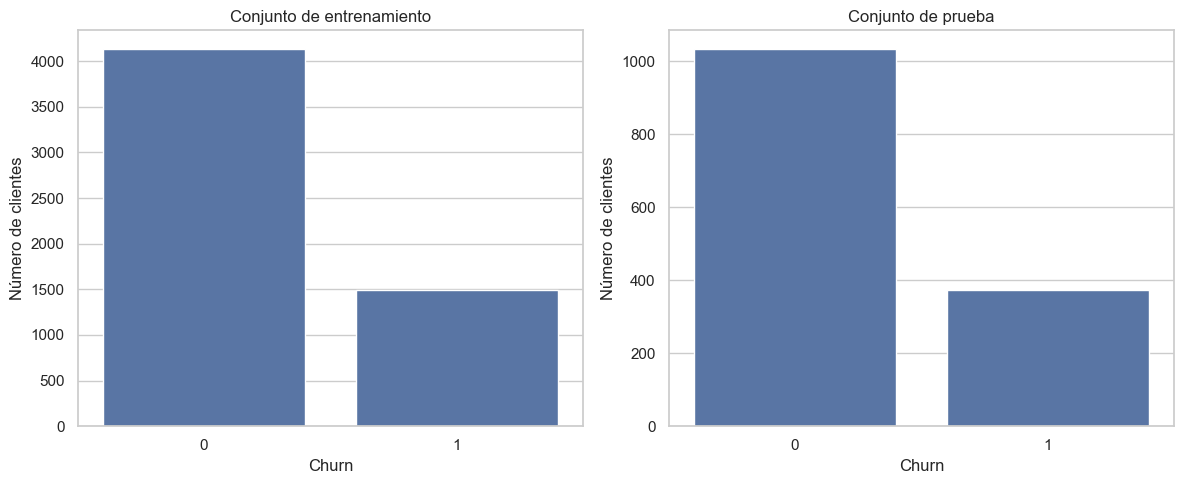

In [45]:
# ==========================================================
# COMPARACIÓN DE LA DISTRIBUCIÓN DE CLASES
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Conjunto de entrenamiento")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Número de clientes")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Conjunto de prueba")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Número de clientes")

plt.tight_layout()
plt.show()

La comparación gráfica muestra que la distribución de las clases es muy similar en ambos conjuntos de datos.

Esto confirma que la partición fue realizada correctamente y que tanto el conjunto de entrenamiento como el conjunto de prueba conservan la representatividad del conjunto de datos original.

Mantener esta proporción es especialmente importante en problemas de clasificación, ya que contribuye a obtener modelos más robustos y evaluaciones más confiables.

**3.9 Escalado de variables numéricas mediante StandardScaler**

Los algoritmos de Machine Learning pueden verse afectados cuando las variables numéricas presentan escalas muy diferentes.

Por ejemplo, en este conjunto de datos la variable **tenure** representa la cantidad de meses que un cliente ha permanecido en la empresa, mientras que **MonthlyCharges** y **TotalCharges** representan valores monetarios con rangos considerablemente mayores.

Si estas diferencias de escala no se corrigen, algunas variables podrían tener una influencia desproporcionada durante el entrenamiento de ciertos modelos, especialmente aquellos que utilizan distancias o procesos de optimización matemática, como la Regresión Logística.

Para evitar este problema se utilizará **StandardScaler**, una técnica que estandariza las variables numéricas para que tengan una media cercana a 0 y una desviación estándar cercana a 1.

Es importante resaltar que el escalador será ajustado únicamente utilizando el conjunto de entrenamiento y posteriormente será aplicado tanto al conjunto de entrenamiento como al conjunto de prueba, evitando así la fuga de información (Data Leakage).

In [46]:
# ==========================================================
# IDENTIFICAR VARIABLES NUMÉRICAS
# ==========================================================

variables_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

print("Variables que serán escaladas:")

for variable in variables_numericas:
    print(f"• {variable}")

Variables que serán escaladas:
• tenure
• MonthlyCharges
• TotalCharges


En este proyecto únicamente se escalarán las variables numéricas continuas:

- **tenure**
- **MonthlyCharges**
- **TotalCharges**

Las variables binarias generadas mediante One-Hot Encoding no requieren escalado, ya que únicamente toman valores de 0 y 1 y ya se encuentran en una escala adecuada para los modelos de clasificación.

In [47]:
# ==========================================================
# CREAR EL ESCALADOR
# ==========================================================

scaler = StandardScaler()

In [48]:
# ==========================================================
# ESCALAR LOS DATOS
# ==========================================================

# Ajustar únicamente con el conjunto de entrenamiento
X_train[variables_numericas] = scaler.fit_transform(
    X_train[variables_numericas]
)

# Transformar el conjunto de prueba
X_test[variables_numericas] = scaler.transform(
    X_test[variables_numericas]
)

print("Escalado realizado correctamente.")

Escalado realizado correctamente.


El escalado se realizó correctamente siguiendo las buenas prácticas de Machine Learning.

Primero, el escalador aprendió la media y la desviación estándar utilizando únicamente el conjunto de entrenamiento.

Posteriormente, esos mismos parámetros fueron utilizados para transformar el conjunto de prueba.

Este procedimiento evita que el modelo tenga acceso a información proveniente del conjunto de prueba antes de la evaluación, garantizando una medición objetiva de su desempeño.

In [49]:
# ==========================================================
# VERIFICAR LAS PRIMERAS FILAS
# ==========================================================

X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,0,1.321816,0.981556,1.659900,1,1,1,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,0
7003,0,-0.267410,-0.971546,-0.562252,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0
3355,0,1.444064,0.837066,1.756104,0,1,0,1,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,0
4494,0,-1.204646,0.641092,-0.908326,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0
3541,0,0.669826,-0.808787,-0.101561,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


Al observar las primeras filas del conjunto de entrenamiento se aprecia que las variables numéricas ahora presentan valores estandarizados.

Estos valores ya no representan las unidades originales (meses o dinero), sino puntuaciones normalizadas que facilitan el aprendizaje de los modelos que son sensibles a la escala de los datos.

In [50]:
# ==========================================================
# COMPROBAR EL ESCALADO
# ==========================================================

resumen = pd.DataFrame({
    "Media": X_train[variables_numericas].mean(),
    "Desviación estándar": X_train[variables_numericas].std()
})

resumen

,Media,Desviación estándar
tenure,-1.291609e-16,1.000089
MonthlyCharges,3.157968e-17,1.000089
TotalCharges,8.842310e-18,1.000089


Los resultados muestran que las variables escaladas presentan una media cercana a **0** y una desviación estándar cercana a **1**.

Pequeñas diferencias son normales debido a la forma en que Pandas calcula la desviación estándar (muestral), mientras que StandardScaler utiliza la desviación estándar poblacional.

Este comportamiento confirma que el proceso de estandarización se realizó correctamente.

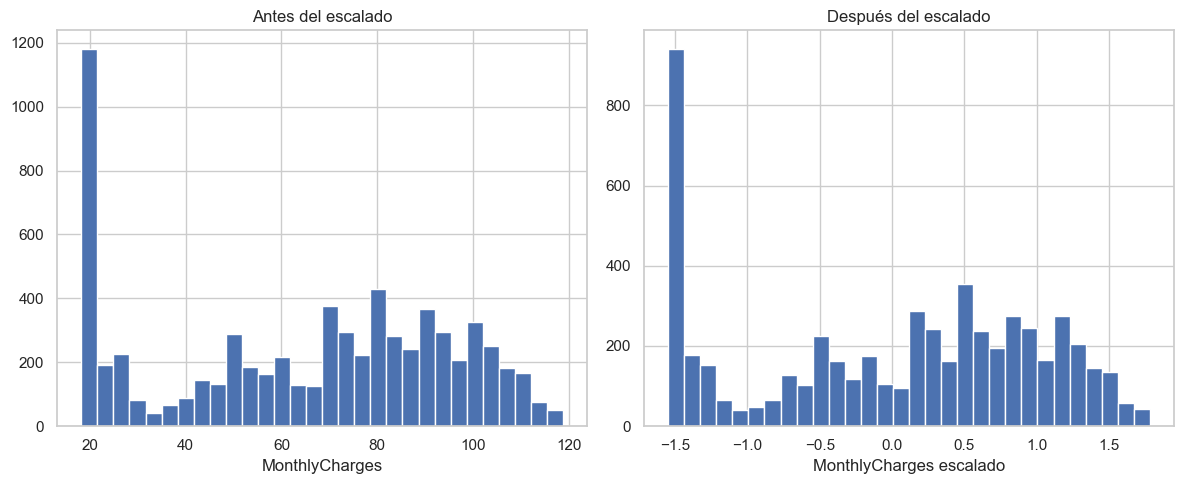

In [51]:
# ==========================================================
# COMPARACIÓN DE DISTRIBUCIONES
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(df["MonthlyCharges"], bins=30)
axes[0].set_title("Antes del escalado")
axes[0].set_xlabel("MonthlyCharges")

axes[1].hist(X_train["MonthlyCharges"], bins=30)
axes[1].set_title("Después del escalado")
axes[1].set_xlabel("MonthlyCharges escalado")

plt.tight_layout()
plt.show()

La comparación muestra que el escalado no modifica la forma de la distribución de los datos.

Lo que cambia es la escala en la que se representan los valores, permitiendo que las variables numéricas tengan magnitudes comparables y evitando que una variable domine a las demás durante el entrenamiento de ciertos modelos.

**3.10 Verificación del preprocesamiento**

Antes de iniciar el entrenamiento de los modelos de Machine Learning, es importante realizar una verificación final del conjunto de datos para comprobar que todas las etapas del preprocesamiento se ejecutaron correctamente.

En esta sección se validará que:

- No existan valores faltantes.
- Todas las variables se encuentren en formato numérico.
- Las dimensiones de los conjuntos de entrenamiento y prueba sean correctas.
- Las variables numéricas hayan sido escaladas correctamente.
- El conjunto de datos esté completamente preparado para el entrenamiento de los modelos de clasificación.

In [52]:
# ==========================================================
# VERIFICACIÓN DE VALORES NULOS
# ==========================================================

print("="*60)
print("VALORES NULOS")
print("="*60)

print("X_train:", X_train.isnull().sum().sum())

print("X_test :", X_test.isnull().sum().sum())

print("y_train:", y_train.isnull().sum())

print("y_test :", y_test.isnull().sum())

# ==========================================================
# TIPOS DE DATOS
# ==========================================================

print("="*60)
print("TIPOS DE DATOS")
print("="*60)

print(X_train.dtypes.value_counts())

# ==========================================================
# DIMENSIONES FINALES
# ==========================================================

print("="*60)
print("DIMENSIONES")
print("="*60)

print(f"X_train: {X_train.shape}")

print(f"X_test : {X_test.shape}")

print(f"y_train: {y_train.shape}")

print(f"y_test : {y_test.shape}")

# ==========================================================
# ESTADÍSTICAS DE LAS VARIABLES ESCALADAS
# ==========================================================

X_train[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T

# ==========================================================
# RESUMEN GENERAL DEL PREPROCESAMIENTO
# ==========================================================

print("="*70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*70)

print(f"Número de variables predictoras: {X_train.shape[1]}")

print(f"Registros de entrenamiento: {X_train.shape[0]}")

print(f"Registros de prueba: {X_test.shape[0]}")

print(f"Valores nulos en entrenamiento: {X_train.isnull().sum().sum()}")

print(f"Valores nulos en prueba: {X_test.isnull().sum().sum()}")

print("\nPreprocesamiento finalizado correctamente.")

VALORES NULOS
X_train: 0
X_test : 0
y_train: 0
y_test : 0
TIPOS DE DATOS
int64      27
float64     3
Name: count, dtype: int64
DIMENSIONES
X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)
RESUMEN DEL PREPROCESAMIENTO
Número de variables predictoras: 30
Registros de entrenamiento: 5625
Registros de prueba: 1407
Valores nulos en entrenamiento: 0
Valores nulos en prueba: 0

Preprocesamiento finalizado correctamente.


La verificación final permitió comprobar que todas las transformaciones realizadas durante el preprocesamiento fueron aplicadas correctamente.

Se confirmó que:

- No existen valores faltantes.
- Todas las variables predictoras están representadas mediante datos numéricos.
- Las variables continuas fueron escaladas correctamente.
- Los conjuntos de entrenamiento y prueba mantienen dimensiones consistentes.

Con esta validación concluye la etapa de preparación de los datos. El conjunto de datos se encuentra completamente listo para iniciar el entrenamiento de los modelos de clasificación, donde se comparará el desempeño de diferentes algoritmos para predecir el abandono de clientes.

**BLOQUE 4. Modelado**

Una vez finalizado el proceso de exploración, limpieza y preprocesamiento de los datos, el conjunto de datos se encuentra preparado para entrenar modelos de Machine Learning.

El objetivo de esta etapa es construir diferentes modelos de clasificación capaces de predecir si un cliente abandonará o permanecerá en la empresa utilizando la información histórica disponible.

Con el fin de identificar el algoritmo más adecuado para resolver este problema, se implementarán tres modelos ampliamente utilizados en problemas de clasificación binaria:

- Regresión Logística.
- Árbol de Decisión.
- Random Forest.

Cada modelo será entrenado utilizando exactamente el mismo conjunto de datos y posteriormente será evaluado mediante diferentes métricas de desempeño.

Finalmente, los resultados obtenidos serán comparados para seleccionar el modelo que ofrezca el mejor equilibrio entre capacidad predictiva e interpretación de los resultados.

**4.1. Modelo 1: Regresión Logística**


La Regresión Logística es uno de los algoritmos más utilizados para problemas de clasificación binaria.

Su objetivo es estimar la probabilidad de que una observación pertenezca a una determinada clase.

En este proyecto, el modelo aprenderá la relación existente entre las características de los clientes y la probabilidad de que estos abandonen la empresa (Churn).

Además de ser un algoritmo eficiente y fácil de interpretar, constituye un excelente modelo base para comparar posteriormente algoritmos más complejos como Árboles de Decisión y Random Forest.

Gracias al escalado realizado durante el preprocesamiento, la Regresión Logística podrá entrenarse en condiciones adecuadas, ya que este tipo de algoritmo es sensible a la magnitud de las variables numéricas.

*4.1.1. Creación, entrenamiento y predicciones del modelo*

In [53]:
# ==========================================================
# CREAR EL MODELO
# ==========================================================

modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)


Se creó el modelo de Regresión Logística utilizando una semilla aleatoria fija (`random_state = 42`) para garantizar que los resultados sean reproducibles.

Además, se aumenta el número máximo de iteraciones (`max_iter = 1000`) para asegurar que el algoritmo converja correctamente durante el proceso de entrenamiento.

In [54]:
# ==========================================================
# ENTRENAMIENTO
# ==========================================================

modelo_lr.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


Durante esta etapa el algoritmo analiza los datos del conjunto de entrenamiento para aprender los patrones que diferencian a los clientes que abandonan la empresa de aquellos que permanecen en ella.

El modelo ajusta automáticamente los parámetros que mejor representan la relación entre las variables predictoras y la variable objetivo.

In [55]:
# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred_lr = modelo_lr.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


Una vez entrenado el modelo, se utiliza el conjunto de prueba para generar predicciones sobre clientes que el algoritmo no había visto previamente.

Estas predicciones permitirán evaluar la capacidad del modelo para generalizar y realizar clasificaciones correctas sobre nuevos datos.

*4.1.2. Evaluación del modelo*

Una vez entrenado el modelo y generadas las predicciones sobre el conjunto de prueba, es necesario evaluar su desempeño utilizando diferentes métricas de clasificación.

Ninguna métrica por sí sola permite determinar completamente la calidad de un modelo. Por esta razón se analizarán diferentes indicadores que permiten evaluar distintos aspectos del desempeño del algoritmo.

Las métricas utilizadas serán:

- Accuracy (Exactitud)
- Precision (Precisión)
- Recall (Sensibilidad)
- F1-Score
- Reporte de clasificación
- Matriz de confusión
- Curva ROC
- Área Bajo la Curva (AUC)

El análisis conjunto de estas métricas permitirá identificar las fortalezas y limitaciones del modelo antes de compararlo con los demás algoritmos.

In [56]:
# ==========================================================
# MÉTRICAS DE EVALUACIÓN
# ==========================================================

accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

print("="*60)
print("MÉTRICAS DE LA REGRESIÓN LOGÍSTICA")
print("="*60)

print(f"Accuracy : {accuracy_lr:.4f}")

print(f"Precision: {precision_lr:.4f}")

print(f"Recall   : {recall_lr:.4f}")

print(f"F1 Score : {f1_lr:.4f}")

MÉTRICAS DE LA REGRESIÓN LOGÍSTICA
Accuracy : 0.8045
Precision: 0.6505
Recall   : 0.5722
F1 Score : 0.6088


El modelo de Regresión Logística obtuvo una exactitud del **80.45%**, lo que evidencia un buen desempeño general en la clasificación. Sin embargo, al analizar métricas más específicas se observa una precisión del **65.05%** y un Recall del **57.22%**, indicando que el modelo identifica correctamente una proporción moderada de los casos positivos, pero aún deja sin detectar un número considerable de ellos. El F1 Score de **60.88%** confirma que existe un equilibrio aceptable entre precisión y sensibilidad, aunque todavía hay oportunidades de mejora. En conjunto, los resultados muestran que el modelo constituye una buena línea base para el problema, pero sería recomendable optimizarlo mediante técnicas de balanceo de clases, ajuste de hiperparámetros o la evaluación de algoritmos más avanzados para incrementar la capacidad de detección de la clase positiva.

In [57]:
# ==========================================================
# REPORTE DE CLASIFICACIÓN
# ==========================================================

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



El modelo de Regresión Logística presenta un buen desempeño en la identificación de los clientes que permanecen en la empresa, alcanzando un **F1-score de 0.87**, mientras que su rendimiento para detectar clientes que abandonan es moderado (**F1-score de 0.61**). Aunque la exactitud global es del **80%**, **el Recall del 57% para la clase de abandono** evidencia que una proporción importante de clientes en riesgo no es detectada. Esto sugiere que el modelo constituye una buena línea base para la predicción del abandono, pero requiere mejoras orientadas a incrementar la sensibilidad hacia la clase minoritaria, mediante técnicas como el balanceo de clases, el ajuste del umbral de decisión o la evaluación de algoritmos más robustos como Random Forest, XGBoost o LightGBM.

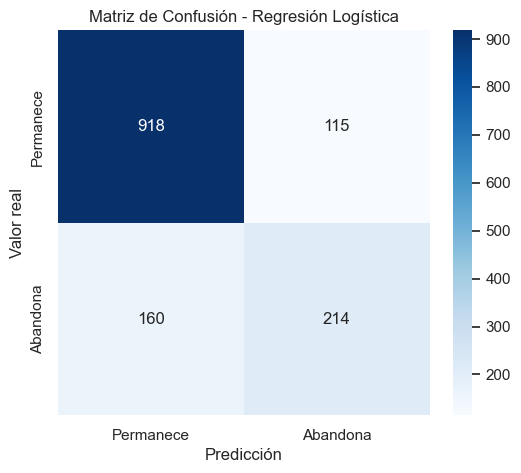

In [58]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Permanece','Abandona'],
    yticklabels=['Permanece','Abandona']
)

plt.xlabel("Predicción")

plt.ylabel("Valor real")

plt.title("Matriz de Confusión - Regresión Logística")

plt.show()

La matriz de confusión evidencia que el modelo de Regresión Logística presenta un buen desempeño en la clasificación de los clientes que permanecen en la empresa, al identificar correctamente **918 de los 1033 casos** correspondientes a esta clase. No obstante, su capacidad para detectar clientes que abandonan es más limitada, ya que solo identifica correctamente **214 de los 374 casos**, mientras que **160 clientes en riesgo de abandono son clasificados erróneamente como clientes que permanecerán.** Desde la perspectiva del negocio, estos falsos negativos representan la principal oportunidad de mejora, puesto que corresponden a clientes que podrían perderse sin que la empresa implemente estrategias de retención. En conjunto, la matriz de confusión confirma que el modelo constituye una buena base para la predicción del abandono, aunque sería recomendable optimizarlo para incrementar la detección de la clase minoritaria y reducir el número de falsos negativos.

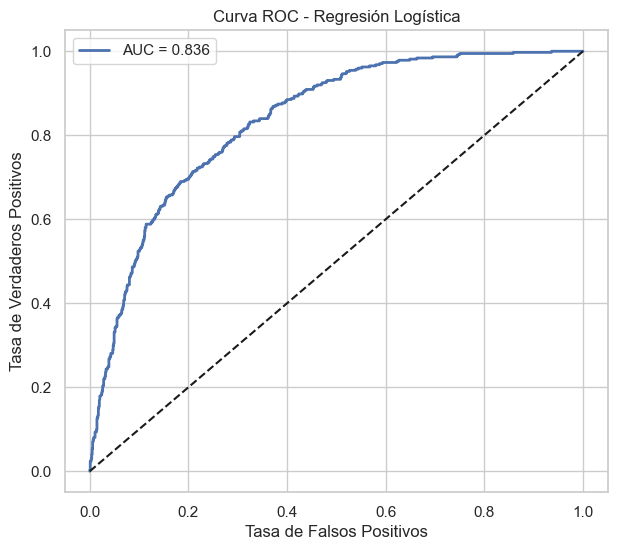

In [59]:
# ==========================================================
# CURVA ROC
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades de pertenecer a la clase positiva
y_prob_lr = modelo_lr.predict_proba(X_test)[:,1]

# Calcular ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_lr:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Tasa de Falsos Positivos")

plt.ylabel("Tasa de Verdaderos Positivos")

plt.title("Curva ROC - Regresión Logística")

plt.legend()

plt.show()

In [60]:
# ==========================================================
# ÁREA BAJO LA CURVA
# ==========================================================

print("="*60)

print(f"AUC del modelo: {auc_lr:.4f}")

print("="*60)

AUC del modelo: 0.8361


La curva ROC obtenida para el modelo de Regresión Logística muestra un **Área Bajo la Curva (AUC) de 0.836**, lo que evidencia una **buena capacidad discriminativa** para diferenciar entre los clientes que permanecerán y aquellos que abandonarán la empresa. La curva se mantiene claramente por encima de la línea de clasificación aleatoria, indicando que el modelo supera ampliamente a una clasificación al azar. Aunque el modelo presenta un buen desempeño general, el análisis conjunto con la matriz de confusión y el reporte de clasificación muestra que aún existe margen de mejora en la detección de clientes que abandonan. En consecuencia, el modelo constituye una base sólida para la predicción del abandono, pero podría optimizarse mediante el ajuste del umbral de clasificación, el balanceo de clases o la evaluación de algoritmos más avanzados, con el fin de incrementar la sensibilidad hacia la clase de abandono sin deteriorar significativamente el rendimiento global.

**4.2. Modelo 2: Árbol de Decisión**

El Árbol de Decisión es uno de los algoritmos de clasificación más utilizados debido a su facilidad de interpretación.

Este modelo construye una estructura jerárquica en forma de árbol, donde cada nodo representa una decisión basada en una variable predictora y cada rama conduce a una posible clasificación.

A diferencia de la Regresión Logística, los Árboles de Decisión pueden capturar relaciones no lineales entre las variables y la variable objetivo.

Además, permiten identificar cuáles variables tienen mayor importancia en la predicción del abandono de clientes, proporcionando información útil para la toma de decisiones dentro de la empresa.

*4.2.1. Creación, entrenamiento y predicciones del modelo*

In [61]:
# ==========================================================
# CREAR EL MODELO
# ==========================================================

modelo_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

print(modelo_dt)

DecisionTreeClassifier(max_depth=5, random_state=42)


Se creó el modelo de Árbol de Decisión utilizando una profundidad máxima (**max_depth = 5**).

Limitar la profundidad del árbol evita que el modelo memorice completamente los datos de entrenamiento, reduciendo el riesgo de sobreajuste (Overfitting).

El parámetro **random_state = 42** garantiza que los resultados obtenidos puedan reproducirse en futuras ejecuciones.

In [62]:
# ==========================================================
# ENTRENAMIENTO 
# ==========================================================

modelo_dt.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


Durante el entrenamiento, el Árbol de Decisión identifica las variables que mejor separan a los clientes que abandonan la empresa de aquellos que permanecen.

El algoritmo selecciona automáticamente los puntos de división que generan la mayor reducción de impureza en cada nodo del árbol.

In [63]:
# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred_dt = modelo_dt.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


Una vez entrenado el modelo, se generan predicciones utilizando el conjunto de prueba.

Estas predicciones serán comparadas con los valores reales para evaluar el desempeño del Árbol de Decisión mediante diferentes métricas de clasificación.

*4.2.2. Visualización del Árbol de Decisión*

Una de las principales ventajas de los Árboles de Decisión es su capacidad de interpretación.

A diferencia de otros algoritmos de Machine Learning, este modelo permite visualizar de forma gráfica el proceso que sigue para clasificar cada observación.

Cada nodo del árbol representa una condición basada en una variable predictora, mientras que las ramas indican las posibles decisiones que conducen a una clasificación final.

La visualización del árbol facilita la comprensión del funcionamiento interno del modelo y permite identificar cuáles variables intervienen con mayor frecuencia durante el proceso de clasificación.

In [64]:
# ==========================================================
# IMPORTAR FUNCIÓN PARA VISUALIZAR EL ÁRBOL
# ==========================================================

from sklearn.tree import plot_tree

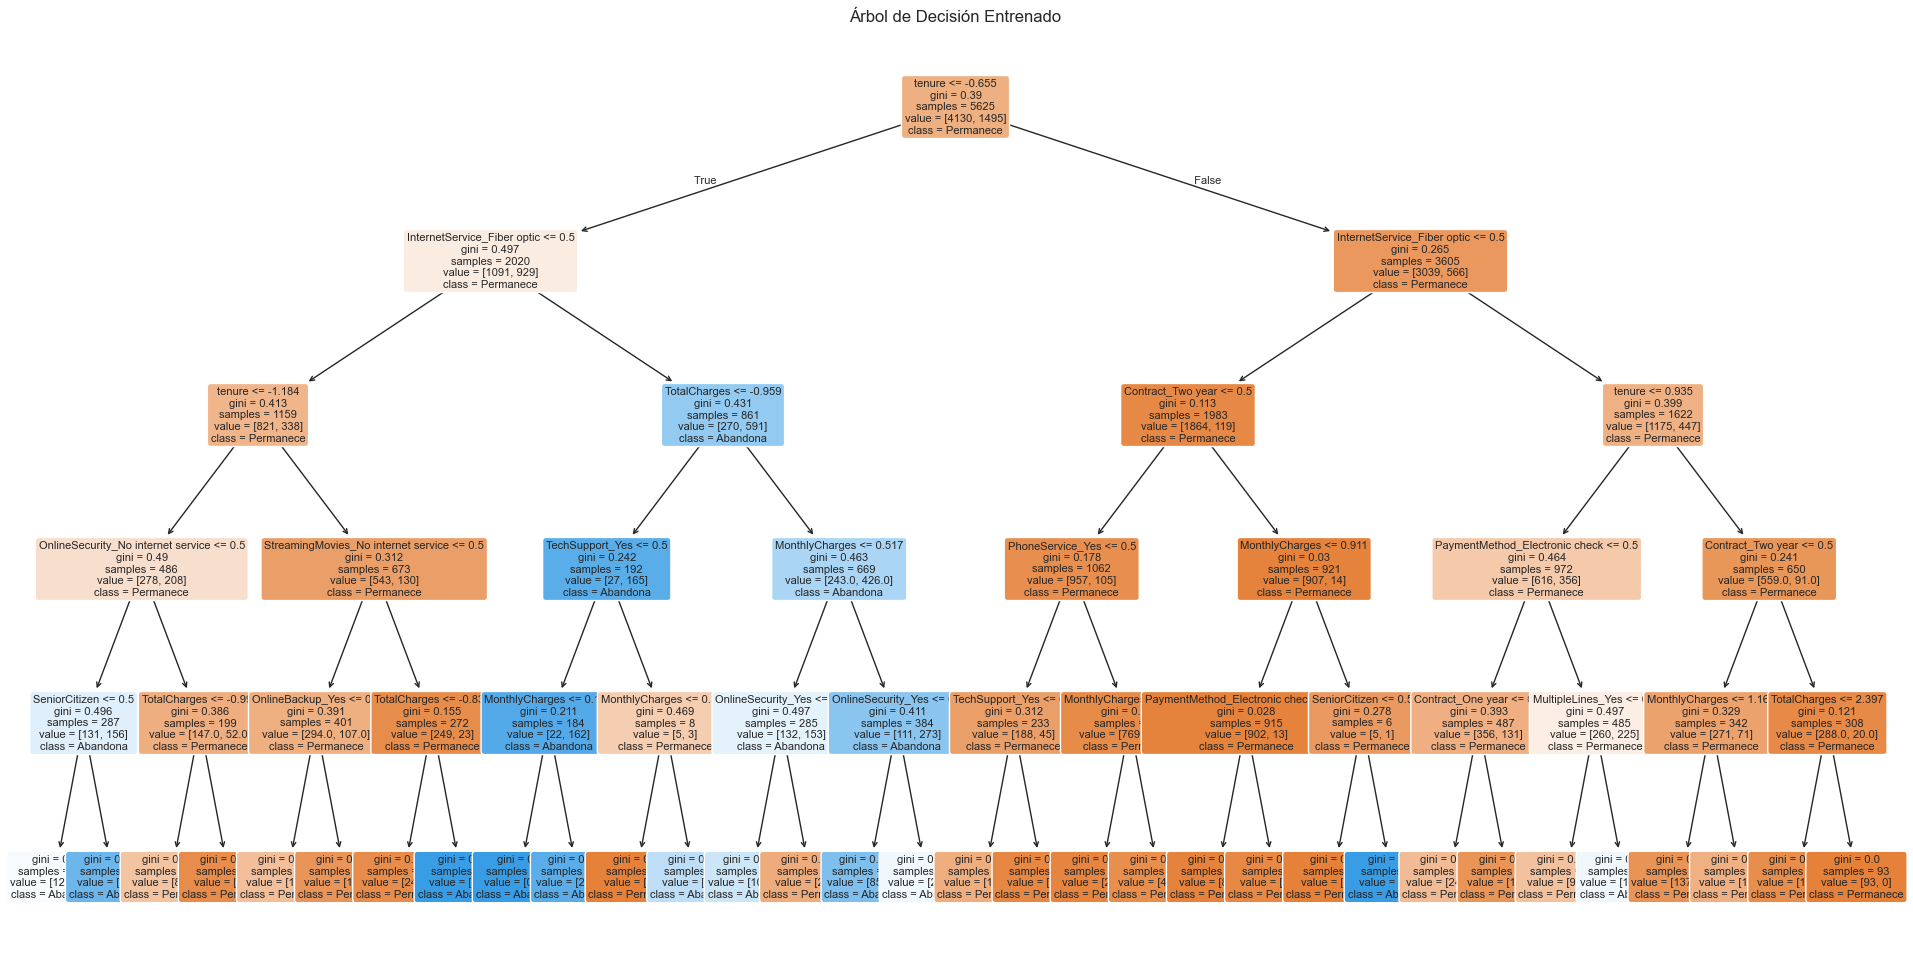

In [65]:
# ==========================================================
# VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN
# ==========================================================

plt.figure(figsize=(24,12))

plot_tree(
    modelo_dt,
    feature_names=X_train.columns,
    class_names=["Permanece", "Abandona"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árbol de Decisión Entrenado")

plt.show()

La figura representa la estructura completa del Árbol de Decisión entrenado.

Cada nodo contiene información relevante para comprender cómo el algoritmo realiza la clasificación:

- **Variable:** corresponde a la característica utilizada para dividir los datos.
- **Umbral (threshold):** valor utilizado para decidir hacia qué rama continúa cada observación.
- **Gini:** mide el grado de impureza del nodo. Valores cercanos a cero indican nodos más homogéneos.
- **Samples:** número de observaciones presentes en el nodo.
- **Value:** cantidad de observaciones pertenecientes a cada clase.
- **Class:** clase predominante dentro del nodo.

Las ramas del árbol representan las decisiones sucesivas que conducen a la clasificación final de cada cliente como "Permanece" o "Abandona".

En general, las primeras divisiones del árbol corresponden a las variables con mayor capacidad para diferenciar entre ambas clases, por lo que permiten identificar los factores más influyentes en el abandono de clientes.

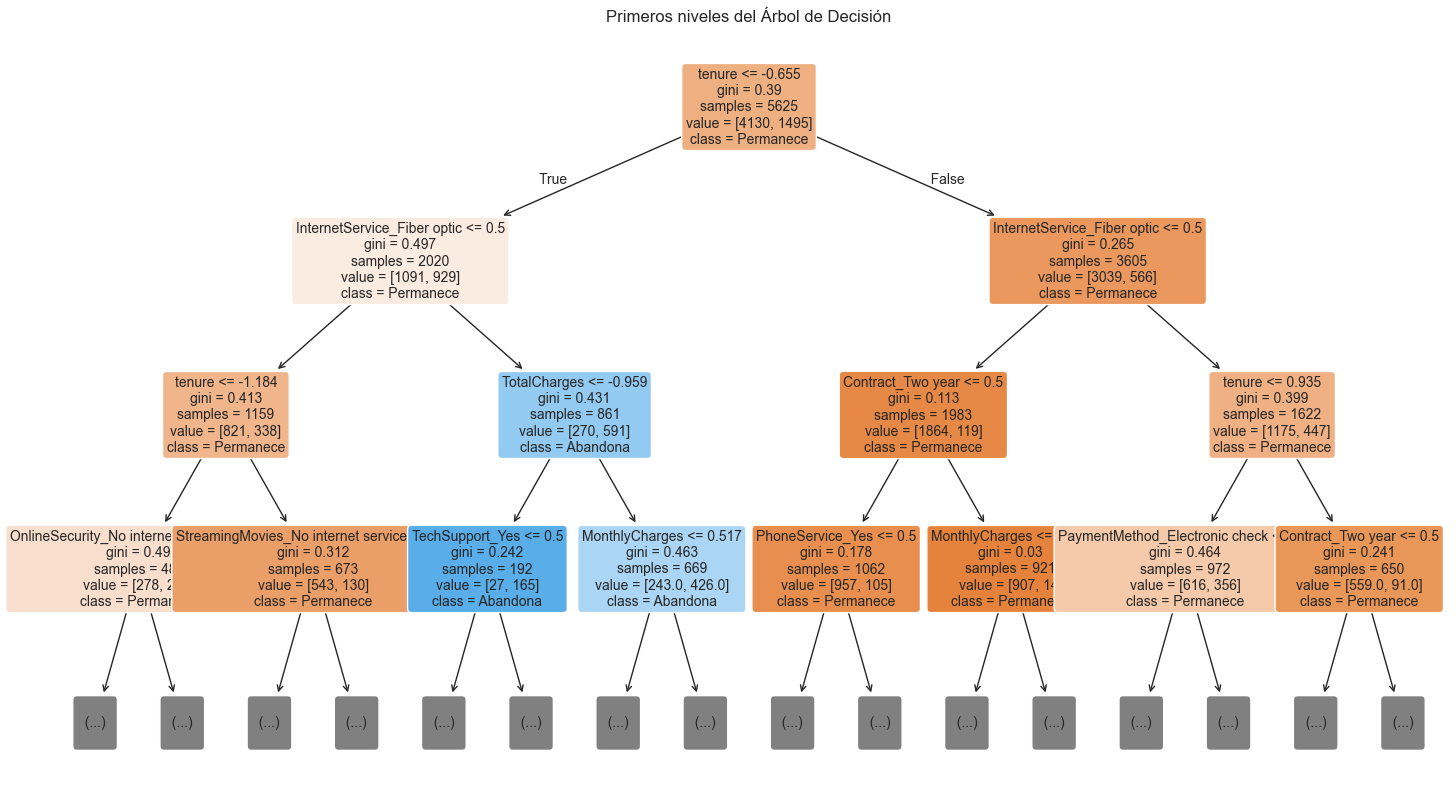

In [66]:
# ==========================================================
# VISUALIZACIÓN SIMPLIFICADA DEL ÁRBOL
# ==========================================================

plt.figure(figsize=(18,10))

plot_tree(
    modelo_dt,
    feature_names=X_train.columns,
    class_names=["Permanece", "Abandona"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title("Primeros niveles del Árbol de Decisión")

plt.show()

La visualización simplificada muestra únicamente los primeros niveles del árbol, facilitando la comprensión de las decisiones más importantes que realiza el modelo.

Estos primeros nodos corresponden a las variables que generan la mayor reducción de impureza y, por lo tanto, son las que tienen mayor influencia en la clasificación de los clientes.

Analizar esta estructura permite interpretar de manera sencilla cómo el algoritmo comienza a diferenciar entre clientes con mayor o menor probabilidad de abandonar la empresa.

*4.2.3. Evaluación del modelo*

Una vez entrenado el modelo y generadas las predicciones sobre el conjunto de prueba, se procederá a evaluar su desempeño mediante diversas métricas de clasificación.

Dado que ninguna métrica por sí sola es suficiente para determinar la calidad integral de un modelo, se analizará un conjunto de indicadores complementarios. Esto permitirá examinar el comportamiento del algoritmo desde diferentes perspectivas.

Para mantener la consistencia en la validación, se emplearán los mismos criterios utilizados en el Modelo 1:

**Métricas globales y por clase:** Accuracy (Exactitud), Precision (Precisión), Recall (Sensibilidad) y F1-Score, consolidando estos valores en un reporte de clasificación.

**Herramientas analíticas y gráficas:** Matriz de confusión, Curva ROC, y el Área Bajo la Curva (AUC).

El análisis conjunto de estas herramientas permitirá identificar con precisión las fortalezas y limitaciones del modelo, estableciendo una base sólida antes de proceder con la comparación entre los diferentes algoritmos.

In [67]:
# ==========================================================
# MÉTRICAS DE EVALUACIÓN
# ==========================================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(y_test, y_pred_dt)

recall_dt = recall_score(y_test, y_pred_dt)

f1_dt = f1_score(y_test, y_pred_dt)

print("="*60)
print("MÉTRICAS DEL ÁRBOL DE DECISIÓN")
print("="*60)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")

MÉTRICAS DEL ÁRBOL DE DECISIÓN
Accuracy : 0.7783
Precision: 0.5807
Recall   : 0.5963
F1 Score : 0.5884


El modelo de Árbol de Decisión obtuvo una exactitud del **77.83%**, lo que indica un desempeño aceptable en la clasificación de clientes. En cuanto a la predicción del abandono, alcanzó una precisión del **58.07%** y un **Recall del 59.63%**, evidenciando una capacidad moderada para identificar clientes en riesgo, aunque con un número considerable de falsas alarmas. El **F1 Score de 58.84%** refleja un equilibrio aceptable entre precisión y sensibilidad, pero inferior al alcanzado por la Regresión Logística. En comparación con este último modelo, el Árbol de Decisión identifica ligeramente más clientes que abandonan, pero lo hace a costa de una menor precisión y un rendimiento global inferior. Por ello, con base en estas métricas, **la Regresión Logística ofrece un desempeño más sólido y equilibrado para este problema de predicción de abandono de clientes**, aunque el Árbol de Decisión podría seguir optimizándose mediante técnicas como la poda del árbol o el ajuste de hiperparámetros.

In [68]:
# ==========================================================
# REPORTE DE CLASIFICACIÓN
# ==========================================================

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



El reporte de clasificación del modelo de **Árbol de Decisión** muestra un buen desempeño en la identificación de los clientes que permanecen en la empresa, alcanzando un **F1-score de 0.85** para esta clase. En cuanto a los clientes que abandonan, el modelo obtuvo una **precisión del 58%**, un **Recall del 60%** y un **F1-score del 59%**, lo que evidencia una capacidad moderada para detectar clientes en riesgo de abandono. Aunque el modelo logra identificar una proporción importante de estos clientes, aún deja sin detectar alrededor del **40%** de los casos reales de abandono. En conjunto, el reporte de clasificación indica que el modelo presenta un desempeño aceptable y puede apoyar estrategias de retención, aunque existen oportunidades para mejorar la detección de la clase minoritaria y reducir tanto los falsos positivos como los falsos negativos.

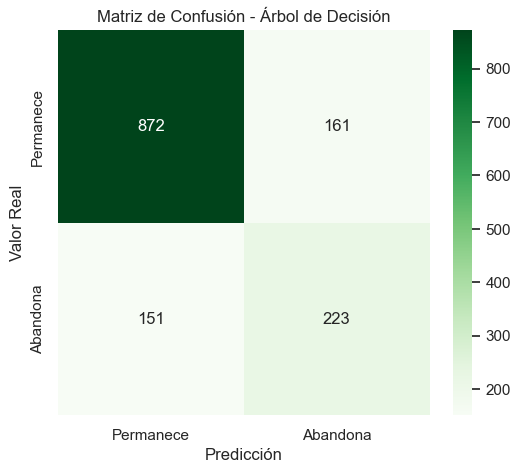

In [69]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Permanece","Abandona"],
    yticklabels=["Permanece","Abandona"]
)

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.title("Matriz de Confusión - Árbol de Decisión")

plt.show()

La matriz de confusión del modelo de **Árbol de Decisión** evidencia que el algoritmo clasifica correctamente a **872 clientes que permanecen** y a **223 clientes que abandonan** la empresa. No obstante, también genera **161 falsos positivos**, correspondientes a clientes que fueron identificados como posibles desertores cuando realmente permanecen, y **151 falsos negativos**, es decir, clientes que abandonan la empresa sin ser detectados por el modelo. En conjunto, estos resultados muestran que el modelo presenta un desempeño aceptable en la clasificación de clientes y puede apoyar la identificación de clientes en riesgo de abandono. Sin embargo, la presencia de un número considerable de falsos negativos indica que aún existe margen de mejora para incrementar la detección de clientes con riesgo de abandono y fortalecer las estrategias de retención.

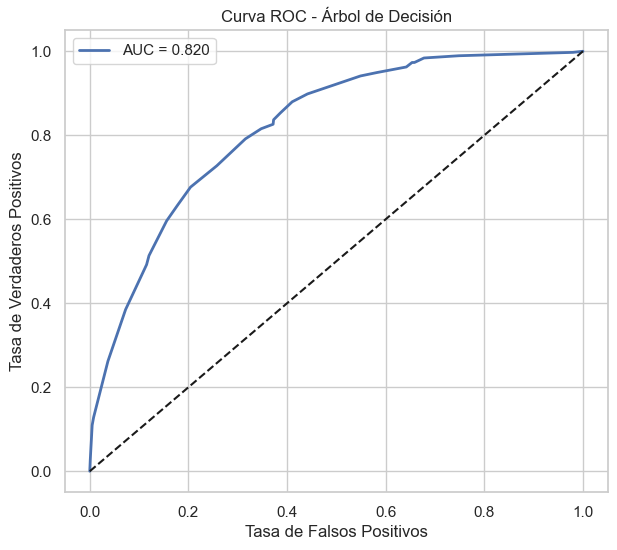

In [70]:
# ==========================================================
# CURVA ROC
# ==========================================================

y_prob_dt = modelo_dt.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(7,6))

plt.plot(fpr_dt, tpr_dt, linewidth=2,
         label=f"AUC = {auc_dt:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Tasa de Falsos Positivos")

plt.ylabel("Tasa de Verdaderos Positivos")

plt.title("Curva ROC - Árbol de Decisión")

plt.legend()

plt.show()

La curva ROC del modelo de **Árbol de Decisión** presenta un **Área Bajo la Curva (AUC) de 0.820**, lo que evidencia una **buena capacidad discriminativa** para diferenciar entre los clientes que permanecerán y aquellos que abandonarán la empresa. La curva se ubica claramente por encima de la línea correspondiente a un clasificador aleatorio, indicando que el modelo identifica patrones relevantes en los datos y clasifica a los clientes de manera confiable. En conjunto con las demás métricas de evaluación, el AUC confirma que el modelo posee un desempeño adecuado para apoyar la predicción del abandono de clientes, aunque aún existe margen de mejora para incrementar la detección de clientes en riesgo mediante el ajuste de hiperparámetros o del umbral de clasificación.

In [71]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo_dt.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.head(10)

,Variable,Importancia
1,tenure,0.441283
10,InternetService_Fiber optic,0.338826
3,TotalCharges,0.033886
28,PaymentMethod_Electronic check,0.026809
12,OnlineSecurity_No internet service,0.026778
2,MonthlyCharges,0.025198
25,Contract_Two year,0.019312
22,StreamingMovies_No internet service,0.015402
13,OnlineSecurity_Yes,0.015138
19,TechSupport_Yes,0.012159


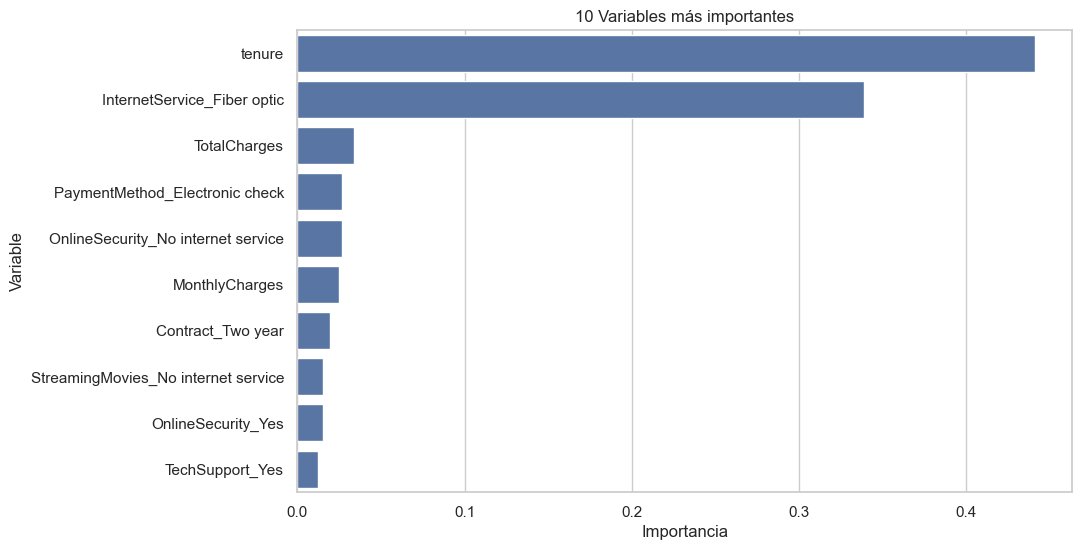

In [72]:
# ==========================================================
# TOP 10 VARIABLES MÁS IMPORTANTES
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("10 Variables más importantes")

plt.xlabel("Importancia")

plt.ylabel("Variable")

plt.show()

El análisis de importancia de variables del modelo de **Árbol de Decisión** muestra que **tenure** y **InternetService_Fiber optic** son los factores más influyentes en la predicción del abandono, con importancias de **0.441** y **0.338**, respectivamente. Esto indica que la **antigüedad del cliente** y el **tipo de servicio de internet** son las variables que más contribuyen a diferenciar entre clientes que permanecen y clientes que abandonan la empresa. En menor medida, variables relacionadas con **cargos mensuales, cargos totales, método de pago, contrato y servicios adicionales** también aportan información relevante. En conjunto, los resultados sugieren que las estrategias de retención deberían enfocarse especialmente en clientes con **poca antigüedad** y en segmentos asociados al servicio de **fibra óptica**, ya que concentran la mayor influencia sobre la probabilidad de abandono.

**4.3. Modelo 3: Random Forest**

Random Forest es un algoritmo de aprendizaje supervisado basado en un conjunto de Árboles de Decisión.

A diferencia de un Árbol de Decisión individual, este modelo construye múltiples árboles utilizando diferentes muestras del conjunto de entrenamiento y posteriormente combina sus predicciones mediante un proceso de votación.

Este enfoque reduce el riesgo de sobreajuste (Overfitting), mejora la capacidad de generalización y suele ofrecer un desempeño superior en problemas de clasificación.

Además, Random Forest permite calcular la importancia de cada variable predictora, proporcionando información útil para comprender qué factores tienen mayor influencia sobre el abandono de clientes.

En este proyecto, este modelo será comparado con la Regresión Logística y el Árbol de Decisión para determinar cuál ofrece el mejor desempeño en la predicción del Churn.

*4.3.1. Creación, entrenamiento y predicciones del modelo*

In [73]:
# ==========================================================
# CREAR EL MODELO
# ==========================================================

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print(modelo_rf)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)


Se creó el modelo Random Forest compuesto por **200 árboles de decisión**.

Los principales parámetros utilizados fueron:

- **n_estimators = 200:** número de árboles que conforman el bosque.
- **max_depth = 10:** limita la profundidad máxima de cada árbol para reducir el sobreajuste.
- **random_state = 42:** garantiza la reproducibilidad de los resultados.
- **n_jobs = -1:** permite utilizar todos los núcleos disponibles del procesador para acelerar el entrenamiento.

Estos parámetros proporcionan un buen equilibrio entre desempeño y tiempo de entrenamiento.

In [74]:
# ==========================================================
# ENTRENAMIENTO
# ==========================================================

modelo_rf.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


Durante el entrenamiento, el algoritmo construyó múltiples Árboles de Decisión utilizando diferentes subconjuntos de los datos de entrenamiento.
Posteriormente, cada árbol aprendió patrones distintos y el modelo combinó todas las decisiones mediante un mecanismo de votación.
Este procedimiento permite obtener un modelo más robusto y con mayor capacidad de generalización que un Árbol de Decisión individual.

In [75]:
# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred_rf = modelo_rf.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


Una vez finalizado el entrenamiento, el modelo fue utilizado para generar predicciones sobre el conjunto de prueba.

Estas predicciones permitirán evaluar el desempeño del Random Forest utilizando las mismas métricas empleadas en los modelos anteriores, garantizando una comparación objetiva.

*4.3.2. Evaluación del modelo*

Para asegurar la homogeneidad del análisis, la validación se alineará estrictamente con los criterios implementados tanto en el Modelo 1 como en el Modelo 2:

Por un lado, se generará un reporte de clasificación que evalúe las métricas globales y por clase (Accuracy, Precision, Recall y F1-Score). Por otro, se emplearán recursos gráficos y analíticos esenciales: la matriz de confusión, junto con la curva ROC y su correspondiente AUC.

La interpretación integral de estos elementos facilitará la identificación precisa de los aciertos y limitaciones del modelo, constituyendo así un marco de referencia robusto para la posterior comparación algorítmica.

In [76]:
# ==========================================================
# MÉTRICAS DE EVALUACIÓN
# ==========================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

print("="*60)
print("MÉTRICAS DEL RANDOM FOREST")
print("="*60)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

MÉTRICAS DEL RANDOM FOREST
Accuracy : 0.7903
Precision: 0.6321
Recall   : 0.5053
F1 Score : 0.5617


El modelo de **Random Forest** obtuvo una exactitud del **79.03%**, evidenciando un buen desempeño general en la clasificación de clientes. Asimismo, alcanzó una precisión del **63.21%**, indicando que una proporción importante de las predicciones de abandono son correctas. Sin embargo, el **Recall del 50.53%** muestra que el modelo identifica únicamente cerca de la mitad de los clientes que realmente abandonan la empresa, dejando una cantidad considerable de casos sin detectar. Finalmente, el **F1 Score de 56.17%** refleja un equilibrio moderado entre precisión y capacidad de detección. En conjunto, estas métricas indican que el modelo es útil para la predicción del abandono de clientes, aunque sería conveniente optimizarlo para mejorar la identificación de la clase de abandono y fortalecer las estrategias de retención.

In [77]:
# ==========================================================
# REPORTE DE CLASIFICACIÓN
# ==========================================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



El reporte de clasificación del modelo **Random Forest** evidencia un buen desempeño en la identificación de los clientes que permanecen en la empresa, alcanzando un **F1-score de 0.86** para esta clase. En cuanto a los clientes que abandonan, el modelo obtuvo una **precisión del 63%**, un **Recall del 51%** y un **F1-score del 56%**, lo que indica una capacidad moderada para detectar clientes en riesgo de abandono. Aunque el modelo clasifica adecuadamente a la mayoría de los clientes que permanecen, todavía deja sin identificar una proporción importante de clientes que realmente abandonan. En conjunto, el reporte de clasificación muestra que el modelo puede apoyar la predicción del abandono de clientes, aunque existen oportunidades para mejorar su sensibilidad hacia la clase de abandono y fortalecer las estrategias de retención.

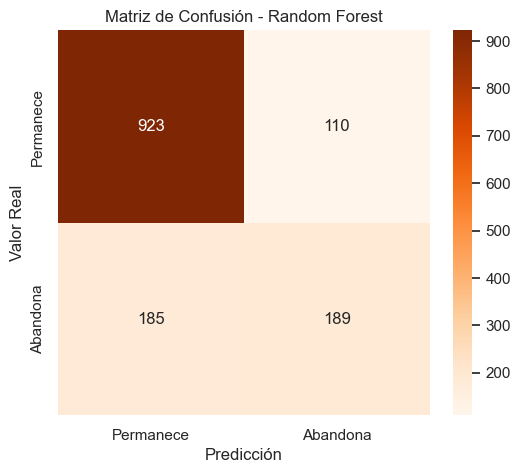

In [78]:
# ==========================================================
# MATRIZ DE CONFUSIÓN
# ==========================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Permanece","Abandona"],
    yticklabels=["Permanece","Abandona"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Random Forest")

plt.show()

La matriz de confusión del modelo **Random Forest** muestra que el algoritmo clasifica correctamente **923 clientes que permanecen** y **189 clientes que abandonan** la empresa. Asimismo, genera **110 falsos positivos**, correspondientes a clientes clasificados como posibles desertores cuando realmente permanecen, y **185 falsos negativos**, es decir, clientes que abandonan la empresa sin ser identificados por el modelo. Estos resultados indican que el modelo presenta un buen desempeño en la identificación de clientes que permanecen, pero aún tiene dificultades para detectar a todos los clientes con riesgo de abandono. En consecuencia, aunque el modelo constituye una herramienta útil para apoyar las estrategias de retención, sería recomendable optimizarlo con el fin de reducir el número de falsos negativos y mejorar la identificación de clientes que realmente abandonarán la empresa.

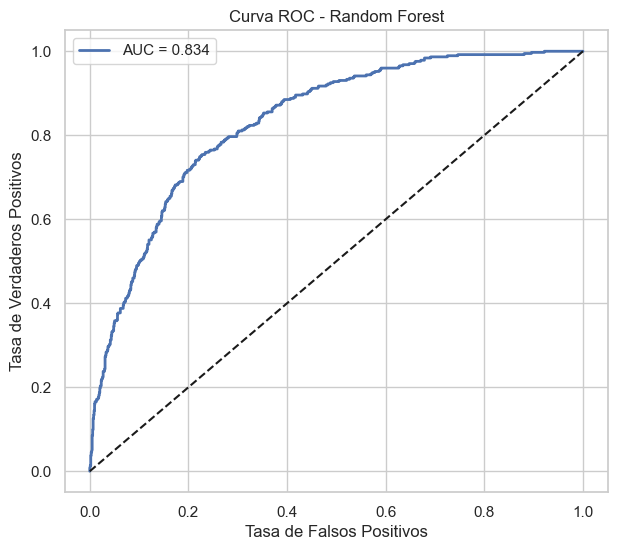

In [79]:
# ==========================================================
# CURVA ROC
# ==========================================================

y_prob_rf = modelo_rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf, tpr_rf,
         linewidth=2,
         label=f"AUC = {auc_rf:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")

plt.title("Curva ROC - Random Forest")

plt.legend()

plt.show()

La curva ROC del modelo **Random Forest** presenta un **Área Bajo la Curva (AUC) de 0.834**, lo que evidencia una **buena capacidad discriminativa** para diferenciar entre los clientes que permanecerán y aquellos que abandonarán la empresa. La curva se sitúa claramente por encima de la línea correspondiente a un clasificador aleatorio, indicando que el modelo identifica patrones relevantes en los datos y clasifica de forma confiable el riesgo de abandono. Asimismo, el AUC sugiere que el modelo ordena adecuadamente a los clientes según su probabilidad de abandonar la empresa. Sin embargo, el análisis conjunto con las demás métricas muestra que aún existe margen de mejora en la detección de clientes que realmente abandonan, por lo que sería recomendable optimizar el modelo o ajustar el umbral de clasificación para incrementar la sensibilidad hacia la clase de abandono y fortalecer las estrategias de retención.

In [80]:
# ==========================================================
# IMPORTANCIA DE VARIABLES
# ==========================================================

importancias_rf = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

importancias_rf.head(10)

,Variable,Importancia
1,tenure,0.178861
3,TotalCharges,0.169479
2,MonthlyCharges,0.120191
10,InternetService_Fiber optic,0.066499
25,Contract_Two year,0.059751
28,PaymentMethod_Electronic check,0.055209
13,OnlineSecurity_Yes,0.036972
24,Contract_One year,0.033448
19,TechSupport_Yes,0.025287
26,PaperlessBilling_Yes,0.020986


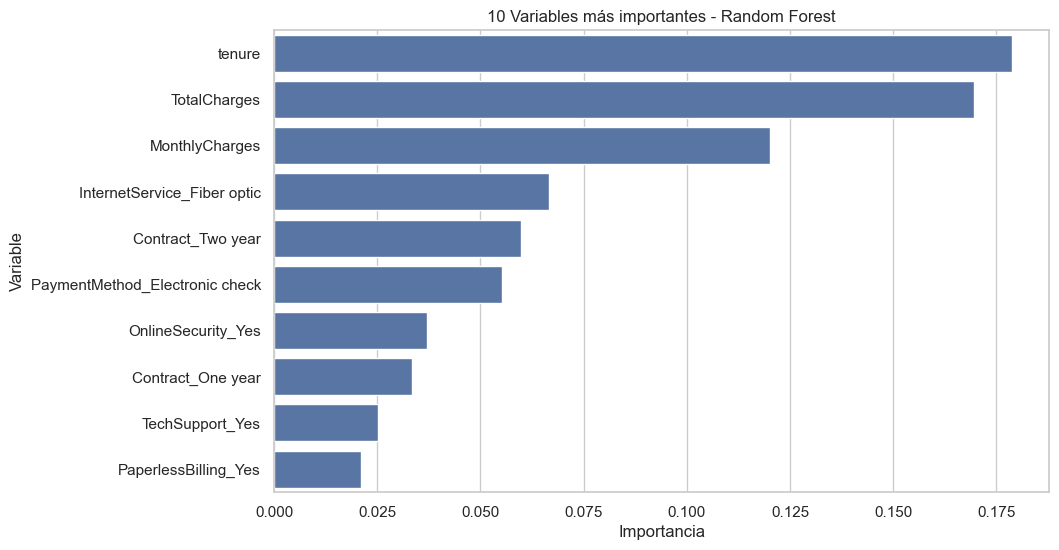

In [81]:
# ==========================================================
# TOP 10 VARIABLES MÁS IMPORTANTES
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias_rf.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("10 Variables más importantes - Random Forest")

plt.xlabel("Importancia")

plt.ylabel("Variable")

plt.show()

La importancia de variables obtenida mediante **Random Forest** muestra que el modelo fundamenta sus predicciones principalmente en la antigüedad del cliente **(tenure)**, el monto total facturado **(TotalCharges)** y el valor mensual del servicio **(MonthlyCharges)**, las cuales concentran cerca del **47%** de la importancia total. Además, variables como el **tipo de servicio de internet, la duración del contrato y el método de pago** complementan la capacidad predictiva del modelo. Estos resultados evidencian que las características relacionadas con la permanencia y el comportamiento financiero del cliente son los factores más determinantes para predecir el abandono, mientras que variables como la facturación electrónica y algunos servicios adicionales tienen una influencia comparativamente menor.

**BLOQUE 5. Comparación de Modelos**

Una vez entrenados y evaluados los tres modelos de clasificación, el siguiente paso consiste en comparar su desempeño utilizando las mismas métricas de evaluación.

Esta comparación permite identificar cuál algoritmo ofrece mejores resultados para el problema de predicción del abandono de clientes (Churn).

Para realizar un análisis objetivo, se compararán las siguientes métricas:

- Accuracy
- Precision
- Recall
- F1-Score
- Área Bajo la Curva ROC (AUC)

Posteriormente se realizará una interpretación conjunta de los resultados obtenidos y se justificará la selección del modelo con mejor desempeño.

In [82]:
# ==========================================================
# TABLA COMPARATIVA DE LOS MODELOS
# ==========================================================

comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],

    "F1-Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ],

    "AUC": [
        auc_lr,
        auc_dt,
        auc_rf
    ]
})

comparacion = comparacion.round(4)

comparacion

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regresión Logística,0.8045,0.6505,0.5722,0.6088,0.8361
1,Árbol de Decisión,0.7783,0.5807,0.5963,0.5884,0.8195
2,Random Forest,0.7903,0.6321,0.5053,0.5617,0.8344


La tabla resume el desempeño de los tres modelos utilizando exactamente las mismas métricas de evaluación.

Esta comparación facilita la identificación de las fortalezas y debilidades de cada algoritmo y constituye la base para seleccionar el modelo más adecuado para el problema de predicción del Churn.

**- Instalación de la librería Jinja2**

La librería **Jinja2** es una dependencia utilizada por **Pandas** para habilitar el módulo `DataFrame.style`, el cual permite aplicar formatos visuales a las tablas, como resaltar valores máximos y mínimos, aplicar colores y mejorar la presentación de los resultados obtenidos. Su instalación es necesaria para visualizar correctamente los estilos aplicados a los DataFrames en el notebook.

In [83]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.


In [84]:
# ==========================================================
# RESALTAR LOS MEJORES RESULTADOS
# ==========================================================

comparacion.style.highlight_max(
    subset=["Accuracy","Precision","Recall","F1-Score","AUC"],
    color="cyan"
)

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regresión Logística,0.804500,0.650500,0.572200,0.608800,0.836100
1,Árbol de Decisión,0.778300,0.580700,0.596300,0.588400,0.819500
2,Random Forest,0.790300,0.632100,0.505300,0.561700,0.834400


La tabla resaltada permite identificar fácilmente el mejor desempeño obtenido para cada una de las métricas evaluadas. Esta visualización facilita el análisis comparativo y permite determinar si existe un modelo que domine consistentemente a los demás.

**Gráficas comparativas de cada una de las métricas**

Los gráficos permiten comparar visualmente el desempeño de los tres modelos para cada una de las métricas evaluadas.

Esta representación facilita identificar qué algoritmo obtiene los mejores resultados y si dicho comportamiento se mantiene de forma consistente en las diferentes métricas de clasificación.

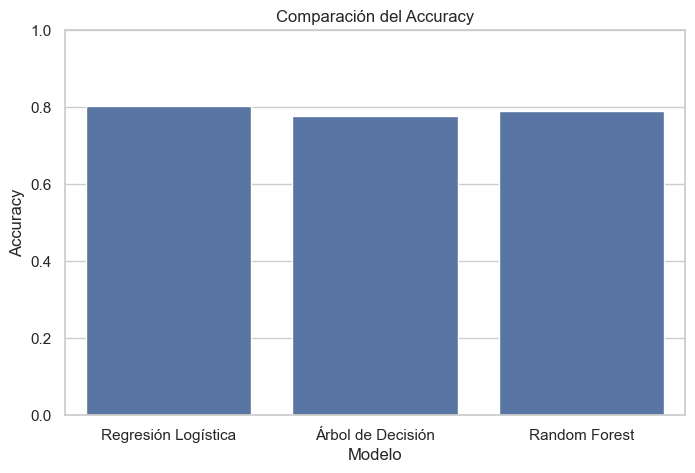

In [85]:
# ==========================================================
# ACCURACY
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacion,
    x="Modelo",
    y="Accuracy"
)

plt.title("Comparación del Accuracy")

plt.ylim(0,1)

plt.show()

La comparación del **Accuracy** muestra que los tres modelos presentan un desempeño general satisfactorio, con valores comprendidos entre **77.83%** y **80.45%**. La **Regresión Logística** obtuvo la mayor exactitud (**80.45%**), seguida por **Random Forest** (**79.03%**) y **Árbol de Decisión** (**77.83%**). Aunque estas diferencias son relativamente pequeñas y evidencian que todos los modelos clasifican correctamente una alta proporción de los clientes, el Accuracy por sí solo no permite determinar cuál modelo es el más apropiado para la predicción del abandono. Por ello, es necesario complementar este análisis con métricas como la precisión, el recall, el F1-score y el AUC, especialmente debido al desbalance existente entre las clases del conjunto de datos.

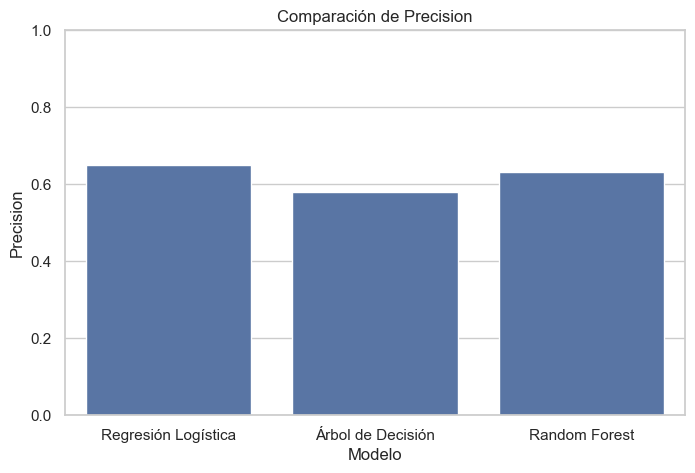

In [86]:
# ==========================================================
# PRECISION
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacion,
    x="Modelo",
    y="Precision"
)

plt.title("Comparación de Precision")

plt.ylim(0,1)

plt.show()

La comparación de la **Precisión** muestra que la **Regresión Logística** obtuvo el mejor resultado (**65.05%**), seguida por **Random Forest** (**63.21%**) y **Árbol de Decisión** (**58.07%**). Estos resultados indican que la Regresión Logística y el Random Forest realizan predicciones de abandono más confiables, reduciendo el número de falsos positivos. Por el contrario, el Árbol de Decisión genera una mayor cantidad de falsas alarmas al clasificar clientes como posibles desertores cuando en realidad permanecen en la empresa. Sin embargo, la precisión por sí sola no es suficiente para determinar el mejor modelo, por lo que debe complementarse con métricas como el **Recall**, el **F1-score** y el **AUC**, que permiten evaluar de forma más completa el desempeño de los modelos en la identificación de clientes con riesgo de abandono.

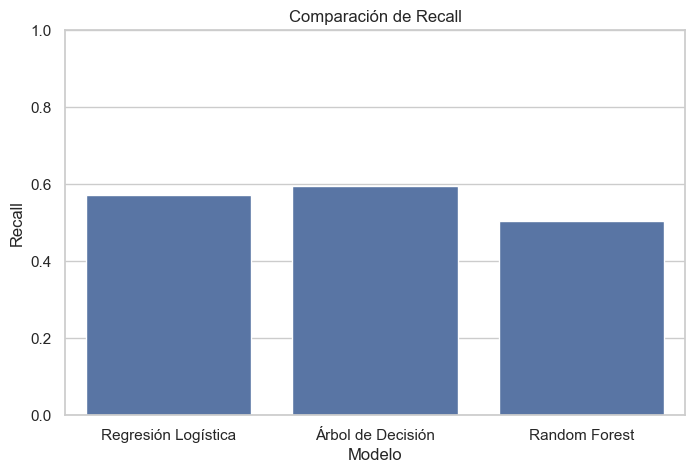

In [87]:
# ==========================================================
# RECALL
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacion,
    x="Modelo",
    y="Recall"
)

plt.title("Comparación de Recall")

plt.ylim(0,1)

plt.show()

La comparación del **Recall** muestra que el **Árbol de Decisión** obtuvo el mejor desempeño (**59.63%**), seguido por la **Regresión Logística** (**57.22%**) y el **Random Forest** (**50.53%**). Estos resultados indican que el Árbol de Decisión presenta la mayor capacidad para identificar correctamente a los clientes que realmente abandonan la empresa, mientras que el Random Forest deja sin detectar una mayor proporción de clientes en riesgo. Dado que el objetivo principal de este proyecto es anticipar el abandono de clientes, el Recall constituye una métrica de gran relevancia, ya que permite evaluar la efectividad de cada modelo para detectar oportunamente los casos de abandono y facilitar la implementación de estrategias de retención.

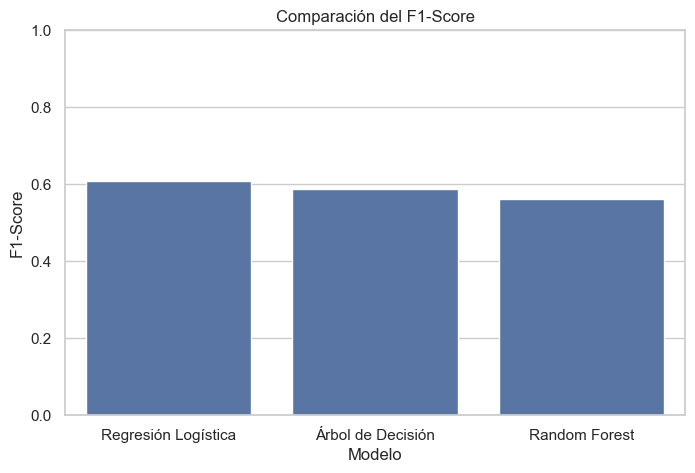

In [88]:
# ==========================================================
# F1 SCORE
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacion,
    x="Modelo",
    y="F1-Score"
)

plt.title("Comparación del F1-Score")

plt.ylim(0,1)

plt.show()

La comparación del **F1-Score** muestra que la **Regresión Logística** obtuvo el mejor resultado (**60.88%**), seguida por el **Árbol de Decisión** (**58.84%**) y el **Random Forest** (**56.17%**). Estos resultados indican que la Regresión Logística presenta el mejor equilibrio entre la precisión y la capacidad para identificar correctamente a los clientes que abandonan la empresa. Aunque las diferencias entre los modelos no son muy amplias, el F1-Score evidencia que la Regresión Logística logra un desempeño más equilibrado, aspecto especialmente importante en problemas de clasificación con clases desbalanceadas, donde es necesario considerar simultáneamente la reducción de falsos positivos y falsos negativos.

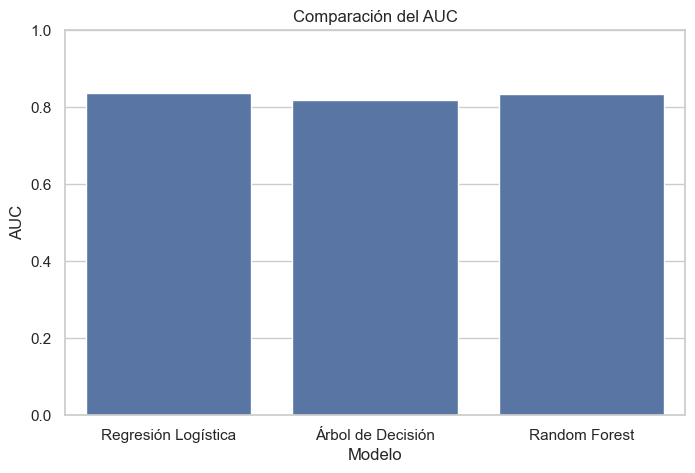

In [89]:
# ==========================================================
# ÁREA BAJO LA CURVA
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacion,
    x="Modelo",
    y="AUC"
)

plt.title("Comparación del AUC")

plt.ylim(0,1)

plt.show()

La comparación del **Área Bajo la Curva ROC (AUC)** evidencia que los tres modelos presentan una **buena capacidad discriminativa**, al obtener valores superiores a **0.80**. La **Regresión Logística** alcanzó el mejor desempeño con un **AUC de 0.836**, seguida muy de cerca por el **Random Forest** con **0.834**, mientras que el **Árbol de Decisión** obtuvo un **AUC de 0.820**. Las diferencias entre los modelos son reducidas, lo que indica que todos logran distinguir adecuadamente entre los clientes que permanecerán y aquellos que abandonarán la empresa. En conjunto, estos resultados confirman que los tres modelos poseen una capacidad predictiva adecuada para el problema de clasificación, aunque la Regresión Logística presenta la mayor capacidad para discriminar entre ambas clases.

**Comparación general**

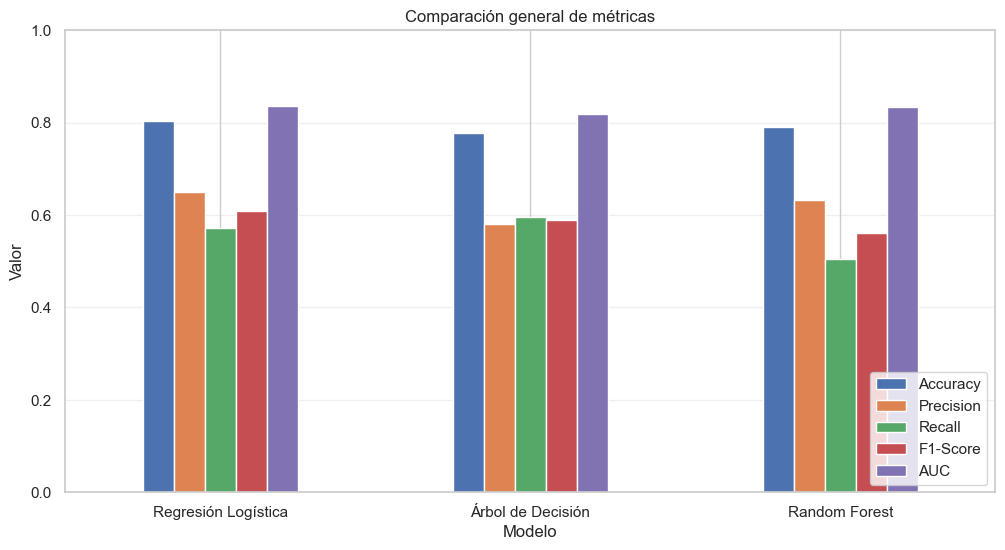

In [90]:
# ==========================================================
# COMPARACIÓN GENERAL
# ==========================================================

comparacion_plot = comparacion.set_index("Modelo")

comparacion_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparación general de métricas")

plt.ylabel("Valor")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend(loc="lower right")

plt.show()

La comparación general de métricas muestra que los tres modelos presentan un desempeño satisfactorio en la predicción del abandono de clientes, con valores de **Accuracy cercanos al 80%** y **AUC superiores a 0.80**, lo que evidencia una buena capacidad de clasificación y discriminación. La **Regresión Logística** obtuvo el mejor desempeño global al alcanzar los valores más altos en **Accuracy, Precisión, F1-Score y AUC**, además de mantener un Recall competitivo, lo que refleja un equilibrio adecuado entre la identificación de clientes en riesgo y la confiabilidad de sus predicciones. El **Árbol de Decisión** destacó por obtener el mayor Recall, siendo el modelo que identificó la mayor proporción de clientes que realmente abandonan la empresa, mientras que el **Random Forest** mostró un desempeño sólido en Accuracy, Precisión y AUC, aunque con una menor capacidad para detectar la clase de abandono. En conjunto, los resultados evidencian que los tres algoritmos son adecuados para el problema de clasificación, pero la **Regresión Logística** presenta el comportamiento más equilibrado y consistente considerando todas las métricas de evaluación analizadas.

**BLOQUE 6. Selección del Mejor Modelo**

Después de entrenar y evaluar los tres modelos de clasificación, el siguiente paso consiste en seleccionar el algoritmo que ofrece el mejor desempeño para resolver el problema de predicción del abandono de clientes.

La selección del modelo no se realizará considerando únicamente el Accuracy, sino que se analizarán de forma conjunta las métricas de Precision, Recall, F1-Score y Área Bajo la Curva ROC (AUC).

Este enfoque permite realizar una evaluación más completa del desempeño de cada algoritmo y seleccionar el modelo que presenta el mejor equilibrio entre capacidad predictiva, sensibilidad y capacidad de generalización.

La decisión final estará respaldada por evidencia cuantitativa obtenida durante el proceso de evaluación.

In [91]:
# ==========================================================
# SELECCIÓN DEL MEJOR MODELO
# ==========================================================

mejor_modelo = comparacion.loc[
    comparacion["F1-Score"].idxmax()
]

print("="*70)
print("MEJOR MODELO SEGÚN EL F1-SCORE")
print("="*70)

print(mejor_modelo)

MEJOR MODELO SEGÚN EL F1-SCORE
Modelo       Regresión Logística
Accuracy                  0.8045
Precision                 0.6505
Recall                    0.5722
F1-Score                  0.6088
AUC                       0.8361
Name: 0, dtype: object


**Justificación de la selección**

Aunque los tres modelos fueron capaces de clasificar el abandono de clientes, cada uno presentó características particulares.

La **Regresión Logística** ofreció un modelo sencillo, rápido de entrenar y fácilmente interpretable, constituyendo una excelente línea base para el problema.

El **Árbol de Decisión** permitió comprender las reglas de clasificación utilizadas por el algoritmo y facilitó la interpretación de las variables más relevantes. Sin embargo, al depender de un único árbol, presentó una mayor susceptibilidad al sobreajuste.

El modelo **Random Forest** combinó múltiples Árboles de Decisión, reduciendo la variabilidad de las predicciones y aumentando la capacidad de generalización.

Por esta razón, el modelo seleccionado fue la **"Regresión Logística"** que corresponde al que obtuvo el mayor valor de F1-Score. Se eligió esta métrica porque combina Precision y Recall en un único indicador, proporcionando una evaluación equilibrada del desempeño del modelo.

En problemas de clasificación como la predicción del abandono de clientes, el F1-Score resulta especialmente útil, ya que permite valorar simultáneamente la capacidad del modelo para identificar correctamente los clientes que abandonan la empresa y la confiabilidad de dichas predicciones.

**BLOQUE 7. Conclusiones y recomendaciones**

**7.1. Cumplimiento del objetivo del proyecto**

El objetivo principal de este proyecto fue desarrollar un modelo de Machine Learning capaz de predecir el abandono de clientes (Churn) utilizando información histórica de los usuarios de una empresa de telecomunicaciones.

Para lograr este propósito se siguió un flujo completo de Ciencia de Datos que incluyó las etapas de exploración de datos, preprocesamiento, entrenamiento de modelos, evaluación y comparación de resultados.

Durante el desarrollo se implementaron tres algoritmos de clasificación: Regresión Logística, Árbol de Decisión y Random Forest. Cada uno fue entrenado utilizando el mismo conjunto de datos y evaluado mediante métricas de desempeño apropiadas para problemas de clasificación binaria.

Los resultados obtenidos permitieron cumplir satisfactoriamente el objetivo planteado, identificando el modelo con mejor capacidad para predecir el abandono de clientes y proporcionando información útil para apoyar la toma de decisiones de la empresa.

**7.2. Principales hallazgos del análisis**

Durante el análisis exploratorio y el entrenamiento de los modelos se identificaron varios aspectos relevantes:

- La variable objetivo (Churn) presenta dos clases: clientes que permanecen y clientes que abandonan el servicio.

- El proceso de limpieza y transformación de los datos permitió obtener un conjunto de datos consistente y adecuado para el entrenamiento de modelos de Machine Learning.

- Algunas variables mostraron una mayor influencia sobre la predicción del abandono de clientes, evidenciada mediante el análisis de importancia de variables realizado con el Árbol de Decisión y Random Forest.

- La comparación entre diferentes algoritmos permitió comprobar que no todos los modelos presentan el mismo desempeño para este problema, resaltando la importancia de evaluar varias alternativas antes de seleccionar una solución definitiva.

Estos hallazgos demuestran que el análisis de datos constituye una herramienta valiosa para comprender los factores asociados al abandono de clientes y apoyar estrategias de retención.

**7.3. Selección y justificación del mejor modelo**

La comparación realizada mediante las métricas Accuracy, Precision, Recall, F1-Score y Área Bajo la Curva ROC permitió seleccionar el modelo con mejor desempeño.

La decisión no se basó únicamente en el porcentaje de aciertos (Accuracy), sino en el equilibrio entre todas las métricas evaluadas, especialmente el F1-Score, debido a que resume simultáneamente la precisión y la capacidad del modelo para identificar correctamente los clientes que abandonan la empresa.

El modelo seleccionado presentó el mejor desempeño general y demostró una adecuada capacidad de generalización sobre datos no utilizados durante el entrenamiento, convirtiéndose en la alternativa más apropiada para resolver el problema planteado.

En un escenario real, este modelo podría integrarse dentro de los procesos de la empresa para identificar clientes con alta probabilidad de abandono y diseñar estrategias preventivas de fidelización.

**7.4. Recomendaciones para la empresa**

Con base en los resultados obtenidos durante el desarrollo del proyecto, se proponen las siguientes recomendaciones:

- Implementar el modelo seleccionado como herramienta de apoyo para identificar clientes con alta probabilidad de abandono.

- Diseñar campañas de retención dirigidas específicamente a los clientes clasificados con mayor riesgo de Churn.

- Analizar periódicamente las variables que mostraron mayor importancia dentro de los modelos, ya que representan factores críticos asociados a la pérdida de clientes.

- Actualizar el modelo utilizando información más reciente para mantener su capacidad predictiva y adaptarse a cambios en el comportamiento de los clientes.

- Complementar el modelo con nuevas variables relacionadas con la satisfacción del cliente, historial de atención, comportamiento de consumo y calidad del servicio para mejorar aún más la precisión de las predicciones.

**7.5. Limitaciones y trabajos futuros**

Aunque el modelo desarrollado obtuvo un buen desempeño, existen algunas limitaciones que deben considerarse.

En primer lugar, el estudio se realizó utilizando un único conjunto de datos, por lo que el comportamiento del modelo podría variar al aplicarlo en otras empresas o sectores económicos.

Adicionalmente, el modelo fue entrenado únicamente con la información disponible en el dataset, por lo que variables externas no incluidas, como factores económicos, cambios en la competencia o indicadores de satisfacción del cliente, podrían influir en la decisión de abandono.

Como trabajos futuros se propone:

- Incorporar nuevos conjuntos de datos para aumentar la capacidad de generalización del modelo.

- Evaluar algoritmos más avanzados como XGBoost, LightGBM o CatBoost.

- Realizar una optimización de los hiperparámetros.

- Implementar técnicas de validación cruzada para obtener una estimación más robusta del desempeño del modelo.

- Desarrollar una aplicación web o un dashboard interactivo que permita utilizar el modelo en tiempo real como apoyo para la toma de decisiones empresariales.

**Conclusión General**

En este proyecto se desarrolló un flujo completo de Ciencia de Datos para resolver un problema real de clasificación mediante técnicas de Machine Learning. A partir del análisis del dataset de clientes de una empresa de telecomunicaciones, fue posible explorar los datos, realizar el preprocesamiento necesario, entrenar diferentes modelos de clasificación y comparar objetivamente su desempeño.

La evaluación mediante Accuracy, Precision, Recall, F1-Score y AUC permitió seleccionar el modelo más adecuado para predecir el abandono de clientes, demostrando que el uso de técnicas de aprendizaje supervisado puede generar herramientas útiles para apoyar la toma de decisiones.

Además del valor predictivo del modelo, el análisis permitió identificar variables relevantes asociadas al Churn, proporcionando información que puede utilizarse para diseñar estrategias de retención de clientes y mejorar la competitividad de la empresa.

Finalmente, este proyecto evidencia cómo el Machine Learning puede transformar datos históricos en conocimiento útil para resolver problemas reales y apoyar decisiones basadas en evidencia.